[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter8_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 8: Advanced volatility modelling

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Quasi-maximum likelihood for GARCH and Bollerslev–Wooldridge standard errors.
- Long-run components: component GARCH and GARCH-MIDAS with macroeconomic drivers.
- Realised measures: the CLT of realised variance, noise, two scales, realised kernels, jumps.
- HAR, HARQ, Realized GARCH, HEAVY and robust forecast evaluation.
- Multivariate: DCC against cDCC, nonlinear shrinkage and DCC-NL, realised correlation.
- Numbers of replications and rebalancings are reduced here to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Realised-measure data

- Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): daily realised measures of six equity indices, 2000-2022; the library is not redistributed with the course: `read_omi` downloads its last public file (28 February 2022) from the Internet Archive and extracts the six indices.
- Our daily realised measures of Bitcoin and Ether from Binance public one-minute prices, 2018-2026, and the one-second signature table of August 2026 (`data/realized/`).
- Variances in %^2 (returns in %).

## Definitions used in the whole notebook

- Data: `read_realized`, `omi`, `binance_daily`, `returns`.
- GARCH and QML: `garch_var`, `garch_lt`, `num_scores`, `num_hessian`, `sandwich`, `fit_garch`.
- GARCH-MIDAS: `beta_weights`, `midas_data`, `gm_components`, `fit_garch_midas`.
- Realised measures: `simulate_intraday`, `rv_k`, `rv_subsampled`, `tsrv`, `realised_kernel`, `bipower`, `tripower`, `ht_stat`.
- Forecasting: `har_X`, `har_forecasts`, `qlike`, `dm_test`, `fit_rgarch`, `fit_heavy`.
- Multivariate: `dcc_loglik`, `fit_dcc`, `cdcc_target`, `lw_linear`, `nl_shrink`, `gmv`.

In [5]:
import time
from scipy import special
from scipy.signal import lfilter
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                 if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
OMI_NAMES = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', '.FTSE': 'FTSE 100', '.N225': 'Nikkei 225', '.STOXX50E': 'Euro Stoxx 50', '.FCHI': 'CAC 40'}
MU1 = np.sqrt(2 / np.pi)
HT_C = np.pi ** 2 / 4 + np.pi - 5
SIM = {'n': 23400, 'mean_iv': 1.0, 'sd_slow': 0.75, 'sd_fast': 0.45, 'hl_slow': 60.0, 'hl_fast': 2.0, 'rho': -0.6, 'lam': 0.08, 'sd_jump': 0.8, 'omega': 0.004}
HAR_WIN = 1000
GMV_ASSETS = ['AAPL.US', 'AMZN.US', 'BAC.US', 'C.US', 'GOOGL.US', 'GS.US', 'JPM.US', 'META.US', 'MS.US', 'MSFT.US', 'MSTR.US', 'NVDA.US', 'TSLA.US', 'WFC.US', 'SPY.US', 'QQQ.US', 'RSP.US']


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def omi(symbol='.SPX'):
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): one index, daily, returns in %
    and variances in %^2; days with a non-positive measure are dropped."""
    d = read_omi()
    d = d[d['symbol'] == symbol].set_index('date').sort_index()
    out = pd.DataFrame({'rv': 1e4 * d['rv5'], 'rv_ss': 1e4 * d['rv5_ss'], 'bv': 1e4 * d['bv'],
                        'medrv': 1e4 * d['medrv'], 'rk': 1e4 * d['rk_parzen'], 'rsv': 1e4 * d['rsv'],
                        'oc': 100 * d['open_to_close'], 'nobs': d['nobs']})
    return out[(out[['rv', 'bv', 'rk', 'medrv']] > 0).all(axis=1)].dropna()


def binance_daily(coin='btc'):
    """Our daily realised measures of Bitcoin or Ether from Binance one-minute prices (UTC days, %, %^2)."""
    d = read_realized('binance_daily_realized.csv', parse_dates=['date'], index_col='date')
    c = [x for x in d.columns if x.startswith(coin + '_')]
    out = d[c].rename(columns=lambda x: x[len(coin) + 1:]).dropna()
    out = out[(out[['rv5', 'bv5', 'rk1']] > 0).all(axis=1)]
    if 'rcov5' in d.columns:
        out['rcov5'] = d['rcov5'].reindex(out.index)
    return out


def returns(name, start='2000-01-01', end=None):
    """Daily log returns in %."""
    p = load_close(name, start=start, end=end) if end else load_close(name, start=start)
    return (100 * np.log(p).diff()).dropna()


def garch_var(e, omega, alpha, beta, gamma=0.0, s0=None):
    """Conditional variances of a (GJR-)GARCH(1,1) by a linear filter:
    s_t = omega + (alpha + gamma 1[e_{t-1} < 0]) e_{t-1}^2 + beta s_{t-1}, s_1 = s0 (sample variance)."""
    e = np.asarray(e, float)
    s0 = np.var(e) if s0 is None else s0
    x = np.empty_like(e)
    x[0] = s0
    x[1:] = omega + (alpha + gamma * (e[:-1] < 0)) * e[:-1] ** 2
    return lfilter([1.0], [1.0, -beta], x)


def t_logpdf_std(z, nu):
    """Log density of a Student-t standardised to unit variance."""
    return (special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
            - (nu + 1) / 2 * np.log1p(z ** 2 / (nu - 2)))


def garch_lt(theta, e, dist='normal', gjr=False):
    """Per-observation log-likelihood of a (GJR-)GARCH(1,1) with Gaussian or standardised Student-t innovations."""
    omega, alpha, beta = theta[:3]
    gamma = theta[3] if gjr else 0.0
    s = garch_var(e, omega, alpha, beta, gamma)
    if dist == 'normal':
        return -0.5 * (np.log(2 * np.pi) + np.log(s) + e ** 2 / s)
    nu = theta[-1]
    return t_logpdf_std(e / np.sqrt(s), nu) - 0.5 * np.log(s)


def num_scores(f, theta, h=1e-5):
    """Numerical per-observation scores (T x k) of a per-observation log-likelihood f(theta)."""
    theta = np.asarray(theta, float)
    out = []
    for j in range(len(theta)):
        d = np.zeros_like(theta)
        d[j] = h * max(1.0, abs(theta[j]))
        out.append((f(theta + d) - f(theta - d)) / (2 * d[j]))
    return np.column_stack(out)


def num_hessian(f, theta, h=1e-4):
    """Numerical Hessian of the summed log-likelihood, from differences of the summed scores."""
    theta = np.asarray(theta, float)
    k = len(theta)
    H = np.zeros((k, k))
    for j in range(k):
        d = np.zeros(k)
        d[j] = h * max(1.0, abs(theta[j]))
        H[:, j] = (num_scores(f, theta + d).sum(0) - num_scores(f, theta - d).sum(0)) / (2 * d[j])
    return 0.5 * (H + H.T)


def sandwich(f, theta):
    """Hessian-based, outer-product and Bollerslev-Wooldridge (sandwich) standard errors."""
    S = num_scores(f, theta)
    H = num_hessian(f, theta)
    Hi = np.linalg.inv(-H)
    I = S.T @ S
    return dict(se_h=np.sqrt(np.diag(Hi)), se_opg=np.sqrt(np.diag(np.linalg.inv(I))),
                se_bw=np.sqrt(np.diag(Hi @ I @ Hi)), cov_bw=Hi @ I @ Hi)


def fit_garch(e, dist='normal', gjr=False, se=True):
    """(Q)ML of a (GJR-)GARCH(1,1) on demeaned returns e (in %)."""
    e = np.asarray(e, float)
    v = np.var(e)
    x0 = [0.05 * v, 0.08, 0.90] + ([0.05] if gjr else []) + ([8.0] if dist == 't' else [])
    bnds = [(1e-8, 10 * v), (1e-6, 0.6), (0.0, 0.9999)] + ([(-0.3, 0.6)] if gjr else []) + ([(2.2, 200)] if dist == 't' else [])

    def nll(th):
        a = th[1] + (0.5 * th[3] if gjr else 0) + th[2]
        if a >= 0.99999 or (gjr and th[1] + th[3] < 0):
            return 1e10
        val = -garch_lt(th, e, dist, gjr).sum()
        return val if np.isfinite(val) else 1e10
    best = None
    for b0 in (0.90, 0.80, 0.95):
        x = list(x0)
        x[2] = b0
        r = optimize.minimize(nll, x, method='L-BFGS-B', bounds=bnds)
        if best is None or r.fun < best.fun:
            best = r
    th = best.x
    out = dict(theta=th, ll=-best.fun, s=garch_var(e, th[0], th[1], th[2], th[3] if gjr else 0.0))
    if se:
        out.update(sandwich(lambda t: garch_lt(t, e, dist, gjr), th))
    return out


def beta_weights(K, w2):
    """Restricted beta lag polynomial of GARCH-MIDAS (w1 = 1): phi_k proportional to (1 - k/K)^(w2 - 1), k = 1..K."""
    k = np.arange(1, K + 1)
    w = (1 - k / K) ** (w2 - 1) if w2 != 1 else np.ones(K)
    w = np.where(np.isfinite(w), w, 0.0)
    return w / w.sum()


def midas_data(r, X, K=36):
    """Align daily returns with a monthly regressor: for each day, the K lagged monthly values X_{t-1}, ..., X_{t-K}."""
    m = r.index.to_period('M')
    Xp = X.copy()
    Xp.index = Xp.index.to_period('M')
    months = pd.period_range(m.min(), m.max(), freq='M')
    lags = np.full((len(months), K), np.nan)
    for i, mm in enumerate(months):
        for k in range(1, K + 1):
            lags[i, k - 1] = Xp.get(mm - k, np.nan)
    ok = ~np.isnan(lags).any(1)
    keep = set(months[ok])
    sel = np.array([p in keep for p in m])
    idx = {p: i for i, p in enumerate(months)}
    return r[sel], lags, np.array([idx[p] for p in m[sel]]), months


def gm_components(th, e, lags, mi, log_tau=True):
    """GARCH-MIDAS: tau_t (monthly) and g_{i,t} (daily) for theta = (alpha, beta, m, theta_x, w2)."""
    alpha, beta, m, thx, w2 = th
    w = beta_weights(lags.shape[1], w2)
    z = m + thx * (lags @ w)
    tau_m = np.exp(z) if log_tau else z
    tau = tau_m[mi]
    u = e ** 2 / tau
    x = np.empty_like(e)
    x[0] = 1.0
    x[1:] = (1 - alpha - beta) + alpha * u[:-1]
    g = lfilter([1.0], [1.0, -beta], x)
    return tau, g, tau_m


def gm_lt(th, e, lags, mi, log_tau=True):
    tau, g, _ = gm_components(th, e, lags, mi, log_tau)
    s = tau * g
    return -0.5 * (np.log(2 * np.pi) + np.log(s) + e ** 2 / s)


def fit_garch_midas(r, X, K=36, log_tau=True):
    """GARCH-MIDAS of Engle, Ghysels and Sohn (2013), restricted beta weights; Gaussian QML; sandwich s.e."""
    rr, lags, mi, months = midas_data(r, X, K)
    e = (rr - rr.mean()).values
    v = np.var(e)

    def nll(th):
        if th[0] <= 0 or th[1] <= 0 or th[0] + th[1] >= 0.9999 or not (1.0 <= th[4] <= 50):
            return 1e10
        tau, g, _ = gm_components(th, e, lags, mi, log_tau)
        if np.any(tau <= 0) or np.any(~np.isfinite(tau)):
            return 1e10
        val = -gm_lt(th, e, lags, mi, log_tau).sum()
        return val if np.isfinite(val) else 1e10
    best = None
    m0 = np.log(v) if log_tau else v
    for thx0 in ((-0.1, 0.1, -0.5, 0.5) if log_tau else (0.5, 0.05)):
        for w20 in (1.5, 5.0):
            r_ = optimize.minimize(nll, [0.08, 0.90, m0, thx0, w20], method='Nelder-Mead',
                                   options=dict(maxiter=8000, xatol=1e-7, fatol=1e-7))
            if best is None or r_.fun < best.fun:
                best = r_
    th = best.x
    se = sandwich(lambda t: gm_lt(t, e, lags, mi, log_tau), th)
    tau, g, tau_m = gm_components(th, e, lags, mi, log_tau)
    vr = float(np.var(np.log(tau)) / np.var(np.log(tau * g)))
    return dict(theta=th, ll=-best.fun, se=se['se_bw'], tau=pd.Series(tau, rr.index), g=pd.Series(g, rr.index),
                vr=vr, T=len(e), e=e, index=rr.index)


def simulate_intraday(days, rng=None, p=SIM, jumps=True, noise=True):
    """Calibrated two-factor log-SV with leverage, compound Poisson jumps and i.i.d. Gaussian noise, one-second grid
    (n seconds a day, returns in %). Returns efficient log prices X (days x n+1), observed Y, IV and QV per day."""
    rng = rng or np.random.default_rng(SEED)
    n = p['n']
    N = days * n
    dt = 1.0 / n
    phis = [np.exp(-np.log(2) / (p[h] * n)) for h in ('hl_slow', 'hl_fast')]
    sds = [p['sd_slow'], p['sd_fast']]
    eps_p = rng.standard_normal(N)
    w_f = p['rho'] * eps_p + np.sqrt(1 - p['rho'] ** 2) * rng.standard_normal(N)
    w_s = rng.standard_normal(N)
    fac = []
    for ph, sd, w in zip(phis, sds, (w_s, w_f)):
        x0 = sd * rng.standard_normal()
        f = lfilter([sd * np.sqrt(1 - ph ** 2)], [1.0, -ph], w, zi=[ph * x0])[0]
        fac.append(f)
    logv = np.log(p['mean_iv']) - 0.5 * (sds[0] ** 2 + sds[1] ** 2) + fac[0] + fac[1]
    sig2 = np.exp(logv)                       # spot variance in %^2 per day
    dX = np.sqrt(sig2 * dt) * np.r_[eps_p[1:], eps_p[:1]]   # price shock of t+1 correlated with vol shock of t
    iv = (sig2 * dt).reshape(days, n).sum(1)
    J = np.zeros(N)
    if jumps:
        nj = rng.poisson(p['lam'] * days)
        pos = rng.integers(0, N, nj)
        np.add.at(J, pos, p['sd_jump'] * rng.standard_normal(nj))
    dX = (dX + J).reshape(days, n)
    X = np.hstack([np.zeros((days, 1)), np.cumsum(dX, 1)])
    Y = X + (p['omega'] * rng.standard_normal(X.shape) if noise else 0.0)
    qv = iv + (J.reshape(days, n) ** 2).sum(1)
    return X, Y, iv, qv


def rv_k(P, k):
    """Realised variance of the log-price rows P sampled every k seconds."""
    r = np.diff(P[:, ::k], axis=1)
    return (r ** 2).sum(1), r


def rv_subsampled(P, k):
    """Average of the k offset grids (subsampling), each rescaled to the full day."""
    n = P.shape[1] - 1
    out = np.zeros(P.shape[0])
    for o in range(k):
        r = np.diff(P[:, o::k], axis=1)
        out += (r ** 2).sum(1) * n / (n - o) / k
    return out


def tsrv(P, K):
    """Two-scales realised variance (Zhang, Mykland and Ait-Sahalia 2005): RV_avg(K) - (n_bar / n) RV_all."""
    n = P.shape[1] - 1
    nbar = (n - K + 1) / K
    rv_all = (np.diff(P, axis=1) ** 2).sum(1)
    rv_avg = np.mean([(np.diff(P[:, o::K], axis=1) ** 2).sum(1) for o in range(K)], axis=0)
    return (rv_avg - nbar / n * rv_all) / (1 - nbar / n)


def parzen(x):
    x = np.abs(x)
    return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))


def realised_kernel(r, H):
    """Realised kernel with Parzen weights (Barndorff-Nielsen, Hansen, Lunde and Shephard 2008), one day of returns."""
    rk = r @ r
    for h in range(1, H + 1):
        rk += 2 * parzen(h / (H + 1)) * (r[h:] @ r[:-h])
    return rk


def rk_bandwidth(r, r_sparse):
    """BNHLS (2009) rule H = 3.5134 xi^(4/5) n^(3/5), xi^2 = omega^2 / IV, omega^2 = RV/(2n), IV from sparse RV."""
    n = len(r)
    omega2 = (r @ r) / (2 * n)
    xi2 = omega2 / max(r_sparse @ r_sparse, 1e-12)
    return max(1, int(np.ceil(3.5134 * xi2 ** 0.4 * n ** 0.6)))


def bipower(r):
    """Bipower variation of the rows of r (Barndorff-Nielsen and Shephard 2004), small-sample factor n/(n-1)."""
    n = r.shape[-1]
    return MU1 ** -2 * n / (n - 1) * np.sum(np.abs(r[..., 1:]) * np.abs(r[..., :-1]), -1)


def tripower(r):
    """Realised tripower quarticity, an estimator of the integrated quarticity robust to jumps."""
    from math import gamma
    mu43 = 2 ** (2 / 3) * gamma(7 / 6) / gamma(1 / 2)
    n = r.shape[-1]
    a = np.abs(r) ** (4 / 3)
    return n * mu43 ** -3 * n / (n - 2) * np.sum(a[..., 2:] * a[..., 1:-1] * a[..., :-2], -1)


def ht_stat(rv, bv, tq, n):
    """Ratio jump statistic of Huang and Tauchen (2005), max-adjusted; N(0, 1) under no jumps."""
    return ((rv - bv) / rv) / np.sqrt(HT_C / n * np.maximum(1.0, tq / bv ** 2))


def jump_days(d, n, alpha=0.001):
    z = ht_stat(d['rv5'], d['bv5'], d['tq5'], n)
    return z, z > stats.norm.ppf(1 - alpha)


def har_X(rv, extra=None):
    """HAR regressors at t for the target RV_{t+1}: daily RV_t, weekly mean of RV_{t-4..t}, monthly mean of RV_{t-21..t}."""
    rv = pd.Series(rv)
    X = pd.DataFrame({'d': rv, 'w': rv.rolling(5).mean(), 'm': rv.rolling(22).mean()})
    if extra is not None:
        for k, v in extra.items():
            X[k] = v
    return X


def newey_west(X, u, L):
    T = len(u)
    S = (X * u[:, None]).T @ (X * u[:, None]) / T
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        G = (X[l:] * u[l:, None]).T @ (X[:-l] * u[:-l, None]) / T
        S += w * (G + G.T)
    Q = np.linalg.inv(X.T @ X / T)
    return np.sqrt(np.diag(Q @ S @ Q / T))


def ols(y, X):
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    return b, y - X @ b


def qlike(y, f):
    return y / f - np.log(y / f) - 1


def har_forecasts(df, models, win=HAR_WIN, filt='insanity', rq_col='rq', meas='rv'):
    """One-day-ahead rolling-window forecasts of RV_{t+1}. df: columns meas (and bv, rq). Models: 'har', 'harcj',
    'loghar', 'harq'. filt = 'insanity' (Bollerslev, Patton and Quaedvlieg 2016: a forecast outside the range of the
    in-sample RV is replaced by the in-sample mean), 'floor' (a forecast below the smallest in-sample RV is set to it)
    or None (raw forecasts). Column '<model>_out' flags forecasts outside the in-sample range."""
    if filt is True:
        filt = 'insanity'
    rv = df[meas]
    base = har_X(rv)
    cols = {'har': ['d', 'w', 'm']}
    ext = {}
    if 'bv' in df:
        c = df['bv'].clip(upper=rv)
        jj = (rv - c).clip(lower=0)
        ext.update({'cd': c, 'cw': c.rolling(5).mean(), 'cm': c.rolling(22).mean(), 'jd': jj})
        cols['harcj'] = ['cd', 'cw', 'cm', 'jd']
    if rq_col in df:
        ext['dq'] = rv * np.sqrt(df[rq_col])
        cols['harq'] = ['d', 'dq', 'w', 'm']
    X = har_X(rv, ext)
    lX = har_X(np.log(rv))
    y = rv.shift(-1)
    ok = X.notna().all(1) & y.notna()
    idx = np.where(ok.values)[0]
    Xv, yv, lXv = X.values, y.values, lX.values
    colix = {k: [list(X.columns).index(c) for c in v] for k, v in cols.items()}
    F = {m: [] for m in models}
    O = {m: [] for m in models}
    dates = []
    for i in range(win, len(idx)):
        tr = idx[i - win:i]
        t = idx[i]
        ytr = yv[tr]
        lo, hi, mu = ytr.min(), ytr.max(), ytr.mean()
        for mdl in models:
            if mdl == 'loghar':
                A = np.column_stack([np.ones(win), lXv[tr]])
                b, u = ols(np.log(ytr), A)
                f = np.exp(np.r_[1.0, lXv[t]] @ b + 0.5 * u.var())
            else:
                A = np.column_stack([np.ones(win), Xv[tr][:, colix[mdl]]])
                b, _ = ols(ytr, A)
                f = np.r_[1.0, Xv[t, colix[mdl]]] @ b
            O[mdl].append(not (lo <= f <= hi))
            if filt == 'insanity' and not (lo <= f <= hi):
                f = mu
            elif filt == 'floor':
                f = max(f, lo)
            F[mdl].append(f)
        dates.append(y.index[t])
    out = pd.DataFrame(F, index=pd.DatetimeIndex(dates))
    for m in models:
        out[m + '_out'] = O[m]
    out['y'] = y.reindex(out.index).values
    return out


def dm_test(l1, l2, L=None):
    """Diebold-Mariano t-statistic of the loss differential l1 - l2 (Newey-West, L = T^(1/3))."""
    d = np.asarray(l1) - np.asarray(l2)
    T = len(d)
    L = L or int(T ** (1 / 3))
    u = d - d.mean()
    s = u @ u / T
    for l in range(1, L + 1):
        s += 2 * (1 - l / (L + 1)) * (u[l:] @ u[:-l]) / T
    return float(d.mean() / np.sqrt(s / T))


def rgarch_paths(th, r, x):
    """Log-linear Realized GARCH(1,1) of Hansen, Huang and Shek (2012):
    log h_t = omega + beta log h_{t-1} + gamma log x_{t-1};
    log x_t = xi + phi log h_t + tau1 z_t + tau2 (z_t^2 - 1) + u_t, u_t ~ N(0, sigma_u^2)."""
    omega, beta, gamma = th[:3]
    lx = np.log(x)
    inp = np.empty_like(lx)
    inp[0] = np.log(np.var(r))
    inp[1:] = omega + gamma * lx[:-1]
    lh = lfilter([1.0], [1.0, -beta], inp)
    return lh


def rgarch_lt(th, r, x, partial=False):
    omega, beta, gamma, xi, phi, t1, t2, su = th
    lh = rgarch_paths(th, r, x)
    h = np.exp(lh)
    z = r / np.sqrt(h)
    lr = -0.5 * (np.log(2 * np.pi) + lh + z ** 2)
    if partial:
        return lr
    u = np.log(x) - xi - phi * lh - t1 * z - t2 * (z ** 2 - 1)
    return lr - 0.5 * (np.log(2 * np.pi) + np.log(su ** 2) + u ** 2 / su ** 2)


def fit_rgarch(r, x, se=True):
    r = np.asarray(r, float)
    x = np.asarray(x, float)

    def nll(th):
        if not (0 < th[1] < 1) or th[7] <= 0:
            return 1e10
        v = -rgarch_lt(th, r, x).sum()
        return v if np.isfinite(v) else 1e10
    x0 = [0.06, 0.55, 0.40, -0.2, 1.0, -0.07, 0.07, 0.4]
    res = optimize.minimize(nll, x0, method='Nelder-Mead', options=dict(maxiter=20000, xatol=1e-8, fatol=1e-8))
    res = optimize.minimize(nll, res.x, method='BFGS')
    th = res.x
    out = dict(theta=th, ll=-res.fun, ll_r=float(rgarch_lt(th, r, x, partial=True).sum()),
               h=np.exp(rgarch_paths(th, r, x)))
    if se:
        out.update(sandwich(lambda t: rgarch_lt(t, r, x), th))
    return out


def heavy_var(x, omega, alpha, beta, s0):
    inp = np.empty_like(x)
    inp[0] = s0
    inp[1:] = omega + alpha * x[:-1]
    return lfilter([1.0], [1.0, -beta], inp)


def fit_heavy(r, x):
    """HEAVY variance equation of Shephard and Sheppard (2010): h_t = omega + alpha RM_{t-1} + beta h_{t-1}."""
    r = np.asarray(r, float)
    x = np.asarray(x, float)

    def nll(th):
        if th[0] <= 0 or th[1] <= 0 or not (0 <= th[2] < 1):
            return 1e10
        h = heavy_var(x, *th, np.var(r))
        return 0.5 * np.sum(np.log(2 * np.pi) + np.log(h) + r ** 2 / h)
    res = optimize.minimize(nll, [0.05, 0.4, 0.6], method='Nelder-Mead', options=dict(maxiter=5000, xatol=1e-8, fatol=1e-8))
    return dict(theta=res.x, ll=-res.fun, h=heavy_var(x, *res.x, np.var(r)))


def n_params(N):
    k = N * (N + 1) // 2
    return dict(vec=k + 2 * k * k, bekk=k + 2 * N * N, dbekk=k + 2 * N, sbekk=k + 2, dcc=3 * N + 2 + N * (N - 1) // 2)


def dcc_loglik(ab, Z, S, corrected=False, return_R=False):
    """Correlation part of the DCC (Engle 2002) or cDCC (Aielli 2013) log-likelihood for standardised residuals Z
    (T x N) and target S. DCC: Q_t = (1-a-b) S + a z z' + b Q_{t-1}; cDCC: z replaced by Q*_{t-1}^{1/2} z."""
    a, b = ab
    T, N = Z.shape
    Q = S.copy()
    ll = 0.0
    Rs = [] if return_R else None
    for t in range(T):
        d = np.sqrt(np.diag(Q))
        R = Q / np.outer(d, d)
        if return_R:
            Rs.append(R)
        z = Z[t]
        c = np.linalg.cholesky(R)
        w = np.linalg.solve(c, z)
        ll += -np.sum(np.log(np.diag(c))) - 0.5 * (w @ w - z @ z)
        zz = d * z if corrected else z
        Q = (1 - a - b) * S + a * np.outer(zz, zz) + b * Q
    return (ll, Rs) if return_R else ll


def cdcc_target(Z, a, b):
    """Aielli (2013) target: the sample covariance of Q*_{t}^{1/2} z_t, computed along the cDCC recursion."""
    T, N = Z.shape
    S = np.corrcoef(Z.T)
    for _ in range(3):
        Q = S.copy()
        acc = np.zeros((N, N))
        for t in range(T):
            d = np.sqrt(np.diag(Q))
            zz = d * Z[t]
            acc += np.outer(zz, zz)
            Q = (1 - a - b) * S + a * np.outer(zz, zz) + b * Q
        S = acc / T
        dd = np.sqrt(np.diag(S))
        S = S / np.outer(dd, dd)
    return S


def fit_dcc(Z, S=None, corrected=False):
    S = np.corrcoef(Z.T) if S is None else S

    def nll(ab):
        if ab[0] <= 0 or ab[1] <= 0 or ab[0] + ab[1] >= 0.999:
            return 1e10
        if corrected:
            return -dcc_loglik(ab, Z, cdcc_target(Z, *ab), corrected=True)
        return -dcc_loglik(ab, Z, S)
    best = None
    for x0 in ([0.03, 0.95], [0.08, 0.85]):
        r = optimize.minimize(nll, x0, method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-5, maxiter=400))
        if best is None or r.fun < best.fun:
            best = r
    return best.x, -best.fun


def simulate_cdcc(T, a, b, rho, rng):
    S = np.array([[1, rho], [rho, 1]])
    Q = S.copy()
    Z = np.empty((T, 2))
    for t in range(T):
        d = np.sqrt(np.diag(Q))
        R = Q / np.outer(d, d)
        z = np.linalg.cholesky(R) @ rng.standard_normal(2)
        Z[t] = z
        zz = d * z
        Q = (1 - a - b) * S + a * np.outer(zz, zz) + b * Q
    return Z


def lw_linear(X):
    """Ledoit-Wolf (2004) linear shrinkage towards the scaled identity (X demeaned, T x N)."""
    T, N = X.shape
    S = X.T @ X / T
    mu = np.trace(S) / N
    d2 = np.sum((S - mu * np.eye(N)) ** 2) / N
    b2 = sum(np.sum((np.outer(x, x) - S) ** 2) for x in X) / N / T ** 2
    b2 = min(b2, d2)
    return b2 / d2 * mu * np.eye(N) + (d2 - b2) / d2 * S


def nl_shrink(X):
    """Analytical nonlinear shrinkage of Ledoit and Wolf (2020, Annals of Statistics), X demeaned (T x N), N < T."""
    T, N = X.shape
    S = X.T @ X / T
    lam, U = np.linalg.eigh(S)
    lam = np.maximum(lam, 1e-12)
    h = T ** (-1 / 3)
    L = lam[None, :]
    H = h * L
    x = (lam[:, None] - L) / H
    ftil = np.mean(np.maximum(1 - x ** 2 / 5, 0) / H, axis=1) * 3 / (4 * np.sqrt(5))
    ad = np.abs(x)
    with np.errstate(divide='ignore', invalid='ignore'):
        Hf = ((-3 / (10 * np.pi)) * x + (3 / (4 * np.sqrt(5) * np.pi)) * (1 - x ** 2 / 5)
              * np.log(np.abs((np.sqrt(5) - x) / (np.sqrt(5) + x))))
    Hf = np.where(ad == np.sqrt(5), (-3 / (10 * np.pi)) * x, Hf)
    Htil = np.mean(Hf / H, axis=1)
    c = N / T
    dtil = lam / ((np.pi * c * lam * ftil) ** 2 + (1 - c - np.pi * c * lam * Htil) ** 2)
    return (U * dtil) @ U.T


def garch_univariate_std(R, hold=1):
    """Univariate Gaussian GARCH(1,1) for each column: standardised residuals and the variance forecast averaged over
    the next `hold` days (hold = 1: the one-day-ahead variance)."""
    Z = np.empty_like(R)
    nxt = np.empty(R.shape[1])
    for j in range(R.shape[1]):
        e = R[:, j]
        th = fit_garch(e, se=False)['theta']
        s = garch_var(np.r_[e, 0.0], th[0], th[1], th[2])
        Z[:, j] = e / np.sqrt(s[:-1])
        p = th[1] + th[2]
        lr = th[0] / (1 - p)
        nxt[j] = lr + (s[-1] - lr) * np.mean(p ** np.arange(hold))
    return Z, nxt


def gmv(Sig):
    w = np.linalg.solve(Sig, np.ones(len(Sig)))
    return w / w.sum()


def corr_shrunk(X, kind):
    """Shrink the correlation matrix of the columns of X (linear LW or nonlinear), then rescale by the sample s.d."""
    sd = X.std(0)
    Z = (X - X.mean(0)) / sd
    C = lw_linear(Z) if kind == 'lw' else nl_shrink(Z)
    d = np.sqrt(np.diag(C))
    return np.outer(sd, sd) * C / np.outer(d, d)

## 1. QML: Hessian against sandwich standard errors

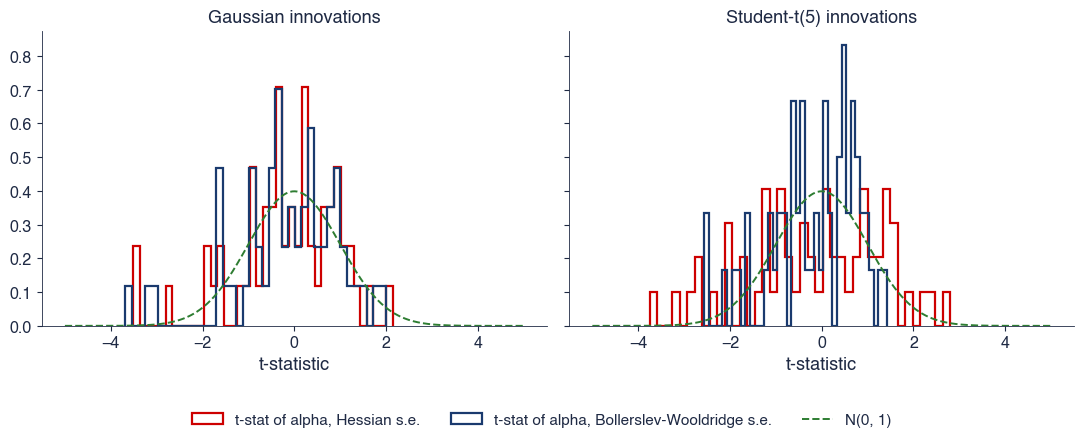

{'normal': {'h': [0.95, 0.9333333333333333, 0.9], 'bw': [0.9333333333333333, 0.9333333333333333, 0.9333333333333333]}, 't5': {'h': [0.8166666666666667, 0.8166666666666667, 0.7833333333333333], 'bw': [0.9166666666666666, 0.95, 0.9333333333333333]}, 'reps': 60, 'T': 2000, 'true': [0.05, 0.08, 0.9]}


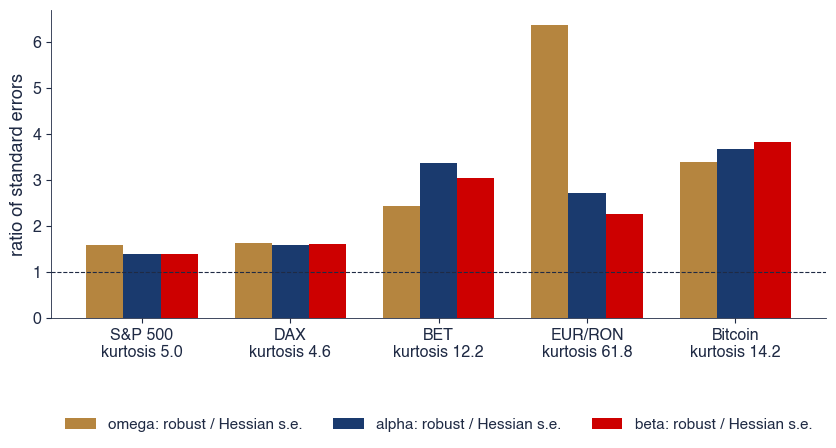

{'sp500': [1.5913163076916026, 1.3781840995530004, 1.3846208917349945], 'dax': [1.6321226939613518, 1.584831270409177, 1.6098577044487234], 'bet': [2.4271367795144108, 3.3610923789841944, 3.0272483984998977], 'eurron': [6.368759656638259, 2.7102371384983104, 2.2563966361600287], 'btc': [3.377837412309163, 3.6666329893194693, 3.8236858319109217]}


In [6]:
def simulate_garch(T, omega, alpha, beta, innov='normal', nu=5, rng=None, burn=500):
    rng = rng or np.random.default_rng(SEED)
    z = rng.standard_normal(T + burn) if innov == 'normal' else rng.standard_t(nu, T + burn) / np.sqrt(nu / (nu - 2))
    e = np.empty(T + burn)
    s = omega / (1 - alpha - beta)
    for t in range(T + burn):
        e[t] = np.sqrt(s) * z[t]
        s = omega + alpha * e[t] ** 2 + beta * s
    return e[burn:]


def fig_qmle_sim(save_it=True, reps=300, T=2000):
    """Monte Carlo: coverage of 95% intervals for alpha and beta with Hessian-based and sandwich standard errors."""
    rng = np.random.default_rng(SEED)
    true = np.array([0.05, 0.08, 0.90])
    res = {}
    for innov in ('normal', 't5'):
        tt = {'h': [], 'bw': []}
        for _ in range(reps):
            e = simulate_garch(T, *true, innov='normal' if innov == 'normal' else 't', rng=rng)
            f = fit_garch(e)
            th = f['theta']
            tt['h'].append((th - true) / f['se_h'])
            tt['bw'].append((th - true) / f['se_bw'])
        res[innov] = {k: np.array(v) for k, v in tt.items()}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
    grid = np.linspace(-5, 5, 400)
    out = {}
    for ax, innov, ttl in zip(axes, ('normal', 't5'), ('Gaussian innovations', 'Student-t(5) innovations')):
        for k, c, lab in (('h', st.IDAred, 'Hessian s.e.'), ('bw', st.MainBlue, 'Bollerslev-Wooldridge s.e.')):
            z = res[innov][k][:, 1]
            z = z[np.isfinite(z)]
            ax.hist(np.clip(z, -5, 5), bins=40, density=True, histtype='step', lw=1.6, color=c, label=f't-stat of alpha, {lab}')
        ax.plot(grid, stats.norm.pdf(grid), color=st.Forest, lw=1.4, ls='--', label='N(0, 1)')
        ax.set_title(ttl)
        ax.set_xlabel('t-statistic')
        cov = {k: [float(np.mean(np.abs(res[innov][k][:, j]) < 1.96)) for j in range(3)] for k in ('h', 'bw')}
        out[innov] = cov
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('ats_ch8_qmle_sim', save_it)
    return dict(out, reps=reps, T=T, true=true.tolist())


def fig_qmle_markets(save_it=True):
    """Gaussian QMLE of GARCH(1,1) in five markets: naive (Hessian) and robust (BW) standard errors; Student-t ML."""
    names = [('sp500', 'S&P 500'), ('dax', 'DAX'), ('bet', 'BET'), ('eurron', 'EUR/RON'), ('btc', 'Bitcoin')]
    rows = {}
    for nm, lab in names:
        r = returns(nm, start='2010-01-01')
        e = (r - r.mean()).values
        f = fit_garch(e)
        ft = fit_garch(e, dist='t', se=False)
        z = e / np.sqrt(f['s'])
        rows[nm] = dict(label=lab, T=len(e), theta=f['theta'].tolist(), se_h=f['se_h'].tolist(), se_bw=f['se_bw'].tolist(),
                        ratio=(f['se_bw'] / f['se_h']).tolist(), kurt=float(stats.kurtosis(z, fisher=False)),
                        nu=float(ft['theta'][-1]), ll_n=f['ll'], ll_t=ft['ll'], pers=float(f['theta'][1] + f['theta'][2]))
    fig, ax = plt.subplots(figsize=(10, 4.0))
    x = np.arange(len(names))
    w = 0.25
    for j, (lab, c) in enumerate(zip(('omega', 'alpha', 'beta'), (st.Amber, st.MainBlue, st.IDAred))):
        ax.bar(x + (j - 1) * w, [rows[nm]['ratio'][j] for nm, _ in names], w, color=c, label=f'{lab}: robust / Hessian s.e.')
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{rows[nm]['label']}\nkurtosis {rows[nm]['kurt']:.1f}" for nm, _ in names])
    ax.set_ylabel('ratio of standard errors')
    st.legend_outside_bottom(ax, ncol=3, y=-0.28)
    save('ats_ch8_qmle_markets', save_it)
    return rows


print(fig_qmle_sim(save_it=False, reps=60))
print({k: v['ratio'] for k, v in fig_qmle_markets(save_it=False).items()})

## 2. Component GARCH and GARCH-MIDAS for the S&P 500

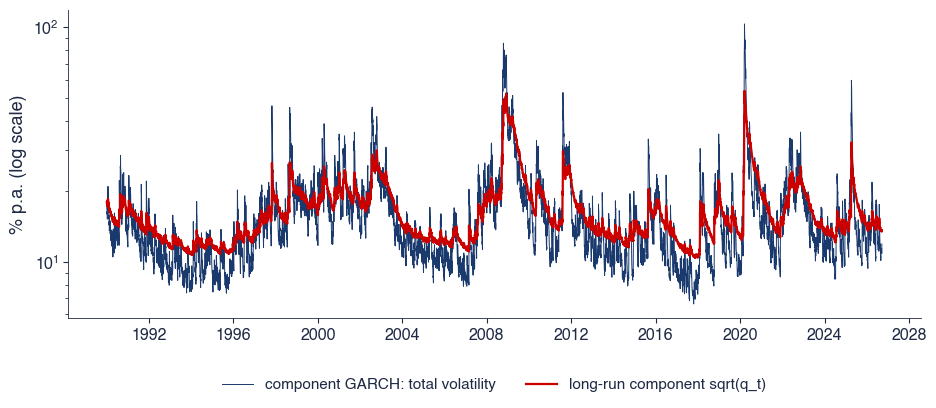

{'theta': [0.004639334296807024, 0.9953802251521947, 0.025962425059836106, 0.08552323784003371, 0.8647125807364242], 'll': np.float64(-12256.77385177527), 'll_garch': np.float64(-12278.810482240468), 'LR': 44.07326093039592, 'hl_long': 149.69232825199686, 'hl_short': 13.579114292017358, 'garch_pers': 0.9831397883803384, 'hl_garch': 40.76386063129736, 'T': 9240, 'first': '1990-01-03'}


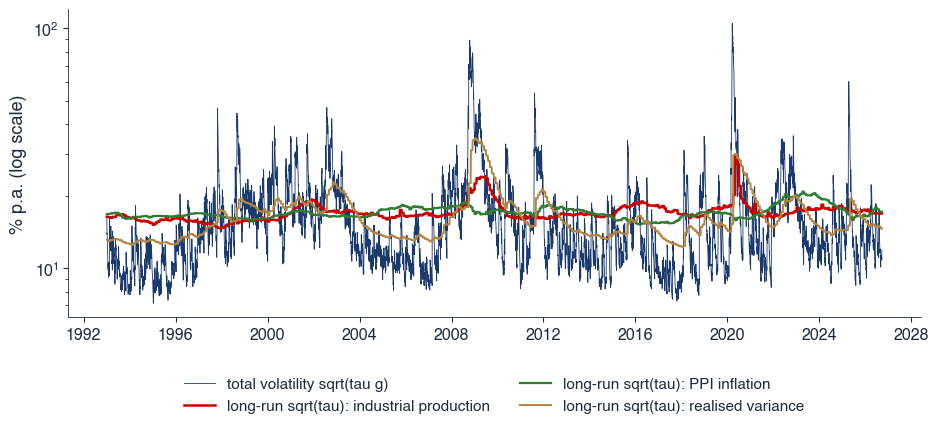

{'ip': {'theta': [0.11031221773948624, 0.8702978766524923, 0.2122189931928227, -0.5509996014957428, 3.69159068226314], 'se': [0.010930469756988134, 0.012333879218085032, 0.15237847902529364, 0.35334307898574063, 1.5606968748751018], 'll': np.float64(-11343.632752630838), 'vr': 0.044556563628954673, 'T': 8482, 'first': '1993-01-04'}, 'ppi': {'theta': [0.10833257282091097, 0.8731655033074439, -0.0008152657239740278, 0.7526404731078602, 1.0000000000052771], 'se': [0.011754880952321247, 0.013119520358036867, 0.28441085977595526, 1.2598931005352303, 5.2051313576437295], 'll': np.float64(-11344.046293446152), 'vr': 0.022305753512113155, 'T': 8482, 'first': '1993-01-04'}, 'rv': {'theta': [0.11869574849803798, 0.8409058340087903, 0.5087106079971904, 0.022508461052024732, 5.939290660448804], 'se': [0.011011743651307896, 0.018701460621744322, 0.1338683030576124, 0.005838638249578749, 2.4156784152926614], 'll': np.float64(-11332.369842169464), 'vr': 0.25118145912323525, 'T': 8482, 'first': '1993-

In [7]:
def cgarch_var(e, omega, rho, phi, alpha, beta):
    """Engle-Lee (1999) component GARCH: q_t = omega + rho q_{t-1} + phi (e_{t-1}^2 - s_{t-1});
    s_t = q_t + alpha (e_{t-1}^2 - q_{t-1}) + beta (s_{t-1} - q_{t-1})."""
    T = len(e)
    s = np.empty(T)
    q = np.empty(T)
    q[0] = s[0] = np.var(e)
    e2 = e ** 2
    for t in range(1, T):
        q[t] = omega + rho * q[t - 1] + phi * (e2[t - 1] - s[t - 1])
        s[t] = q[t] + alpha * (e2[t - 1] - q[t - 1]) + beta * (s[t - 1] - q[t - 1])
    return s, q


def fit_cgarch(e):
    e = np.asarray(e, float)
    v = np.var(e)

    def nll(th):
        omega, rho, phi, alpha, beta = th
        if not (0 < rho < 1 and alpha + beta < rho and phi > 0 and beta > 0 and alpha > 0 and beta > phi):
            return 1e10
        s, q = cgarch_var(e, *th)
        if np.any(s <= 0) or np.any(q <= 0):
            return 1e10
        return 0.5 * np.sum(np.log(2 * np.pi) + np.log(s) + e ** 2 / s)
    x0 = [v * (1 - 0.99), 0.99, 0.03, 0.06, 0.85]
    r = optimize.minimize(nll, x0, method='Nelder-Mead', options=dict(maxiter=6000, xatol=1e-7, fatol=1e-6))
    r = optimize.minimize(nll, r.x, method='Nelder-Mead', options=dict(maxiter=6000, xatol=1e-8, fatol=1e-7))
    s, q = cgarch_var(e, *r.x)
    return dict(theta=r.x, ll=-r.fun, s=s, q=q)


def fig_cgarch(save_it=True):
    r = returns('sp500', start='1990-01-01')
    e = (r - r.mean()).values
    g = fit_garch(e, se=False)
    c = fit_cgarch(e)
    omega, rho, phi, alpha, beta = c['theta']
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ann = np.sqrt(252)
    ax.plot(r.index, ann * np.sqrt(c['s']), color=st.MainBlue, lw=0.7, label='component GARCH: total volatility')
    ax.plot(r.index, ann * np.sqrt(c['q']), color=st.IDAred, lw=1.6, label='long-run component sqrt(q_t)')
    ax.set_yscale('log')
    ax.set_ylabel('% p.a. (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch8_cgarch', save_it)
    hl = lambda p: float(np.log(0.5) / np.log(p))   # noqa: E731
    return dict(theta=c['theta'].tolist(), ll=c['ll'], ll_garch=g['ll'], LR=float(2 * (c['ll'] - g['ll'])),
                hl_long=hl(rho), hl_short=hl(alpha + beta), garch_pers=float(g['theta'][1] + g['theta'][2]),
                hl_garch=hl(g['theta'][1] + g['theta'][2]), T=len(e), first=str(r.index[0].date()))


def macro_us():
    """Monthly US industrial production growth and PPI (finished goods) inflation, % (FRED INDPRO, WPSFD49207)."""
    ip = read_fred('INDPRO')
    ppi = read_fred('WPSFD49207')
    return (100 * np.log(ip).diff()).dropna(), (100 * np.log(ppi).diff()).dropna()


def fig_garch_midas(save_it=True, K=36):
    r = returns('sp500', start='1990-01-01')
    ip, ppi = macro_us()
    rv_m = (r - r.mean()).pow(2).groupby(r.index.to_period('M')).sum()
    rv_m.index = rv_m.index.to_timestamp()
    out = {}
    fits = {}
    # common sample: the first month with K lags of monthly realised variance (returns start in January 1990)
    r = r.loc[str(rv_m.index[K].date()):]
    for nm, X, lt in (('rv', rv_m, False), ('ip', ip, True), ('ppi', ppi, True)):
        f = fit_garch_midas(r, X, K, log_tau=lt)
        fits[nm] = f
        out[nm] = dict(theta=f['theta'].tolist(), se=f['se'].tolist(), ll=f['ll'], vr=f['vr'], T=f['T'],
                       first=str(f['index'][0].date()))
    # GARCH(1,1) on the same sample as the macro models
    e = fits['ip']['e']
    g = fit_garch(e, se=False)
    out['garch_ll'] = g['ll']
    out['bic'] = {k: float(-2 * fits[k]['ll'] + 5 * np.log(fits[k]['T'])) for k in fits}
    out['bic_garch'] = float(-2 * g['ll'] + 3 * np.log(len(e)))
    f = fits['ip']
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ann = np.sqrt(252)
    ax.plot(f['index'], ann * np.sqrt(f['tau'] * f['g']), color=st.MainBlue, lw=0.6, label='total volatility sqrt(tau g)')
    ax.plot(f['index'], ann * np.sqrt(f['tau']), color=st.IDAred, lw=1.8, label='long-run sqrt(tau): industrial production')
    ax.plot(fits['ppi']['index'], ann * np.sqrt(fits['ppi']['tau']), color=st.Forest, lw=1.6, label='long-run sqrt(tau): PPI inflation')
    ax.plot(fits['rv']['index'], ann * np.sqrt(fits['rv']['tau']), color=st.Amber, lw=1.4, label='long-run sqrt(tau): realised variance')
    ax.set_yscale('log')
    ax.set_ylabel('% p.a. (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch8_garch_midas', save_it)
    # the estimated lag weights
    out['w_ip'] = beta_weights(K, f['theta'][4]).tolist()
    out['K'] = K
    out['last_ip'] = str(ip.index[-1].date())
    return out


print(fig_cgarch(save_it=False))
r = fig_garch_midas(save_it=False)
print({k: r[k] for k in ('ip', 'ppi', 'rv', 'bic', 'bic_garch')})

## 3. The CLT of realised variance, noise and realised kernels (simulation)

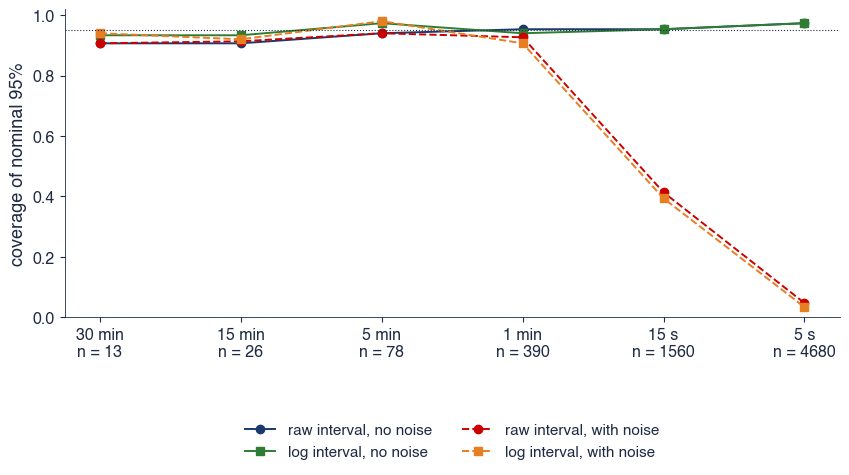

{'k': [1800, 900, 300, 60, 15, 5], 'n': [13, 26, 78, 390, 1560, 4680], 'clean': {'raw': [0.9066666666666666, 0.9066666666666666, 0.94, 0.9533333333333334, 0.9533333333333334, 0.9733333333333334], 'log': [0.9333333333333333, 0.9333333333333333, 0.9733333333333334, 0.94, 0.9533333333333334, 0.9733333333333334]}, 'noisy': {'raw': [0.9066666666666666, 0.9133333333333333, 0.94, 0.9266666666666666, 0.41333333333333333, 0.04666666666666667], 'log': [0.94, 0.92, 0.98, 0.9066666666666666, 0.3933333333333333, 0.03333333333333333]}, 'days': 150, 'iv_mean': 0.8681404879614536}


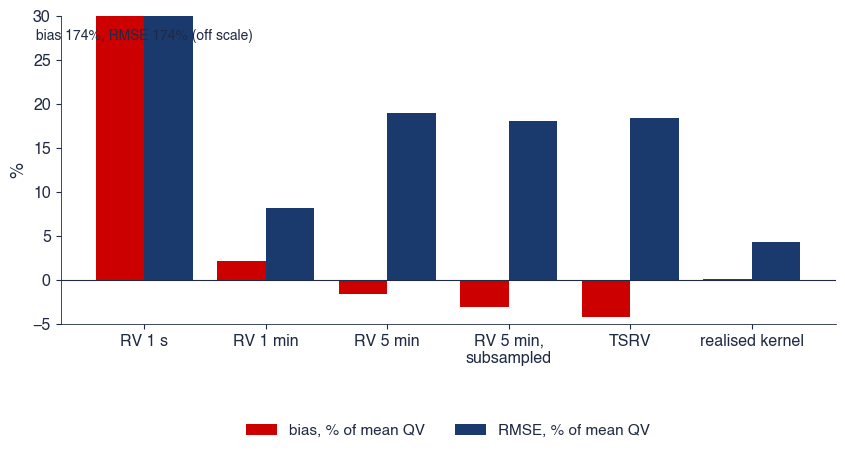

{'RV 1 s': {'bias': 1.7445955085004012, 'rmse': 1.744860861519865}, 'RV 1 min': {'bias': 0.021543914926120757, 'rmse': 0.08126421896431466}, 'RV 5 min': {'bias': -0.015556311420419947, 'rmse': 0.190034304373938}, 'RV 5 min, subsampled': {'bias': -0.03056993857252597, 'rmse': 0.1805313076819283}, 'TSRV': {'bias': -0.04267221438207391, 'rmse': 0.18426147674515328}, 'realised kernel': {'bias': 0.0008224759817434043, 'rmse': 0.04337370189554206}, 'H_med': 34.0, 'days': 80, 'noise_bias_1s': 0.7488, 'xi2': 3.398830006299134e-05, 'jshare': 0.05272802314251668}


In [8]:
def fig_rv_clt(save_it=True, days=400):
    """Coverage of 95% feasible intervals for IV (raw and log), by sampling frequency, without and with noise."""
    rng = np.random.default_rng(SEED + 1)
    X, Y, iv, qv = simulate_intraday(days, rng, jumps=False)
    ks = [1800, 900, 300, 60, 15, 5]
    out = {'k': ks, 'n': [SIM['n'] // k for k in ks]}
    for lab, P in (('clean', X), ('noisy', Y)):
        cr, cl = [], []
        for k in ks:
            rv, r = rv_k(P, k)
            q = (2 / 3) * (r ** 4).sum(1)          # estimated Var(RV): 2 IQ / n with IQ = (n/3) sum r^4
            cr.append(float(np.mean(np.abs(rv - iv) <= 1.96 * np.sqrt(q))))
            cl.append(float(np.mean(np.abs(np.log(rv) - np.log(iv)) <= 1.96 * np.sqrt(q) / rv)))
        out[lab] = dict(raw=cr, log=cl)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    x = np.arange(len(ks))
    ax.plot(x, out['clean']['raw'], 'o-', color=st.MainBlue, label='raw interval, no noise')
    ax.plot(x, out['clean']['log'], 's-', color=st.Forest, label='log interval, no noise')
    ax.plot(x, out['noisy']['raw'], 'o--', color=st.IDAred, label='raw interval, with noise')
    ax.plot(x, out['noisy']['log'], 's--', color=st.Orange, label='log interval, with noise')
    ax.axhline(0.95, color=st.DarkText, lw=0.8, ls=':')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{k // 60} min\nn = {SIM["n"] // k}' if k >= 60 else f'{k} s\nn = {SIM["n"] // k}' for k in ks])
    ax.set_ylabel('coverage of nominal 95%')
    ax.set_ylim(0, 1.02)
    st.legend_outside_bottom(ax, ncol=2, y=-0.3)
    save('ats_ch8_rv_clt', save_it)
    out['days'] = days
    out['iv_mean'] = float(iv.mean())
    return out


def fig_kernels(save_it=True, days=300):
    """RV at several frequencies, subsampled RV, TSRV and the Parzen realised kernel against the true IV and QV."""
    rng = np.random.default_rng(SEED + 2)
    X, Y, iv, qv = simulate_intraday(days, rng)
    est = {}
    est['RV 1 s'] = rv_k(Y, 1)[0]
    est['RV 1 min'] = rv_k(Y, 60)[0]
    est['RV 5 min'] = rv_k(Y, 300)[0]
    est['RV 5 min, subsampled'] = rv_subsampled(Y, 300)
    est['TSRV'] = tsrv(Y, 300)
    rks, Hs = [], []
    for d in range(days):
        r = np.diff(Y[d])
        H = rk_bandwidth(r, np.diff(Y[d, ::1200]))
        Hs.append(H)
        rks.append(realised_kernel(r, H))
    est['realised kernel'] = np.array(rks)
    out = {}
    for k, v in est.items():
        out[k] = dict(bias=float(np.mean(v - qv) / qv.mean()), rmse=float(np.sqrt(np.mean((v - qv) ** 2)) / qv.mean()))
    fig, ax = plt.subplots(figsize=(10, 4.0))
    names = list(est)
    x = np.arange(len(names))
    ax.bar(x - 0.2, [100 * out[k]['bias'] for k in names], 0.4, color=st.IDAred, label='bias, % of mean QV')
    ax.bar(x + 0.2, [100 * out[k]['rmse'] for k in names], 0.4, color=st.MainBlue, label='RMSE, % of mean QV')
    ax.axhline(0, color=st.DarkText, lw=0.8)
    ax.set_ylim(-5, 30)
    top = 100 * out['RV 1 s']['rmse']
    ax.text(0, 28.5, f'bias {100 * out["RV 1 s"]["bias"]:.0f}%, RMSE {top:.0f}% (off scale)', ha='center', va='top',
            color=st.DarkText, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([k.replace(', ', ',\n') for k in names])
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.28)
    save('ats_ch8_kernels', save_it)
    out['H_med'] = float(np.median(Hs))
    out['days'] = days
    out['noise_bias_1s'] = float(2 * SIM['n'] * SIM['omega'] ** 2)
    out['xi2'] = float(SIM['omega'] ** 2 / np.sqrt(np.mean(iv ** 2)))
    out['jshare'] = float(1 - iv.sum() / qv.sum())
    return out


print(fig_rv_clt(save_it=False, days=150))
print(fig_kernels(save_it=False, days=80))

## 4. Signature plot and Epps effect: Bitcoin and Ether; realised volatility across markets

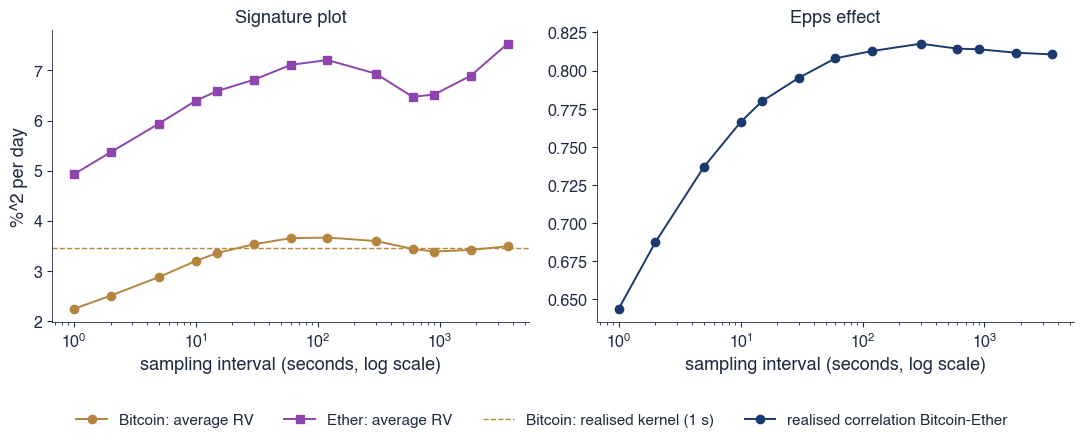

{'days': 31, 'btc': {'1': 2.2364757709677416, '60': 3.6494583225806445, '300': 3.5928271935483873, '1800': 3.4148328064516127}, 'eth': {'1': 4.926221419354839, '60': 7.111490967741935, '300': 6.936393580645162, '1800': 6.895819903225807}, 'corr': {'1': 0.6437296369758033, '60': 0.8080492878851747, '300': 0.8176052392650899, '1800': 0.8117276989033199}, 'rk': 3.4610518387096776, 'H': 21.93548387096774, 'zero': 0.51931, 'ratio_1s_5m': 0.6224835346892732, 'ac1': 0.05892416229186315}


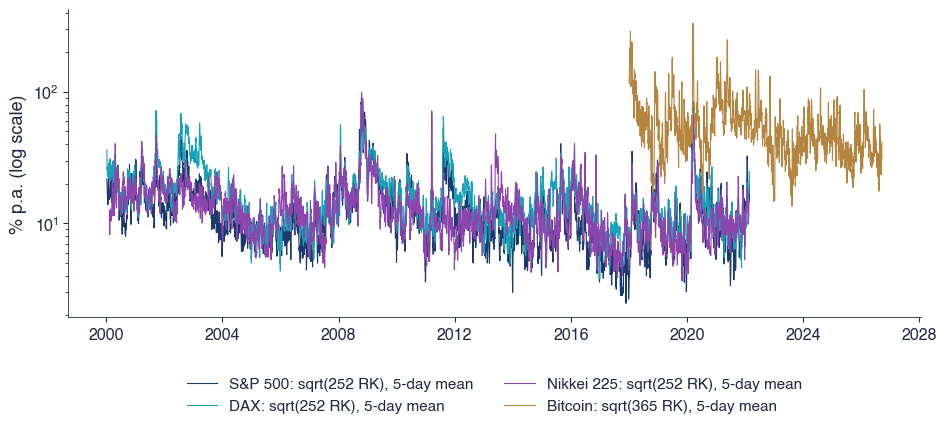

{'.SPX': {'T': 5552, 'mean': 16.170344662098326, 'first': '2000-01-03', 'last': '2022-02-25'}, '.GDAXI': {'T': 5611, 'mean': 19.52320522752934, 'first': '2000-01-03', 'last': '2022-02-25'}, '.N225': {'T': 5381, 'mean': 16.601983298614154, 'first': '2000-02-02', 'last': '2022-02-25'}, 'btc': {'T': 3165, 'mean': 68.356709624837, 'first': '2018-01-02', 'last': '2026-09-18'}}


In [9]:
def fig_signature(save_it=True):
    """Signature plot and Epps effect of Bitcoin and Ether, Binance one-second prices, August 2026."""
    d = read_realized('binance_signature_2026-08.csv', index_col='date')
    secs = [1, 2, 5, 10, 15, 30, 60, 120, 300, 600, 900, 1800, 3600]
    m = d.mean()
    bt = np.array([m[f'btc_rv_{k}'] for k in secs])
    et = np.array([m[f'eth_rv_{k}'] for k in secs])
    co = np.array([m[f'rcov_{k}'] / np.sqrt(m[f'btc_rv_{k}'] * m[f'eth_rv_{k}']) for k in secs])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    ax = axes[0]
    ax.plot(secs, bt, 'o-', color=st.COL['btc'], label='Bitcoin: average RV')
    ax.plot(secs, et, 's-', color=st.Purple, label='Ether: average RV')
    ax.axhline(m['btc_rk'], color=st.COL['btc'], ls='--', lw=1, label='Bitcoin: realised kernel (1 s)')
    ax.set_xscale('log')
    ax.set_xlabel('sampling interval (seconds, log scale)')
    ax.set_ylabel('%^2 per day')
    ax.set_title('Signature plot')
    ax = axes[1]
    ax.plot(secs, co, 'o-', color=st.MainBlue, label='realised correlation Bitcoin-Ether')
    ax.set_xscale('log')
    ax.set_xlabel('sampling interval (seconds, log scale)')
    ax.set_title('Epps effect')
    st.fig_legend_bottom(fig, ncol=4, y=-0.02)
    plt.tight_layout()
    save('ats_ch8_signature', save_it)
    i = {k: secs.index(k) for k in (1, 60, 300, 1800)}
    return dict(days=len(d), btc={str(k): float(bt[j]) for k, j in i.items()}, eth={str(k): float(et[j]) for k, j in i.items()},
                corr={str(k): float(co[j]) for k, j in i.items()}, rk=float(m['btc_rk']), H=float(m['btc_rk_H']),
                zero=float(m['btc_nzero']), ratio_1s_5m=float(bt[0] / bt[secs.index(300)]),
                ac1=float(0.5 * (bt[secs.index(2)] / bt[0] - 1)))


def fig_omi_overview(save_it=True):
    """Daily realised kernel volatility of four indices (OMI) and of Bitcoin (own measure), annualised."""
    fig, ax = plt.subplots(figsize=(11, 4.0))
    out = {}
    for sym, c in (('.SPX', st.MainBlue), ('.GDAXI', st.Teal), ('.N225', st.Purple)):
        d = omi(sym)
        v = np.sqrt(252 * d['rk']).rolling(5).mean()
        ax.plot(v.index, v, color=c, lw=0.8, label=f'{OMI_NAMES[sym]}: sqrt(252 RK), 5-day mean')
        out[sym] = dict(T=len(d), mean=float(np.sqrt(252 * d['rk'].mean())), first=str(d.index[0].date()), last=str(d.index[-1].date()))
    b = binance_daily('btc')
    v = np.sqrt(365 * b['rk1']).rolling(5).mean()
    ax.plot(v.index, v, color=st.COL['btc'], lw=0.8, label='Bitcoin: sqrt(365 RK), 5-day mean')
    out['btc'] = dict(T=len(b), mean=float(np.sqrt(365 * b['rk1'].mean())), first=str(b.index[0].date()), last=str(b.index[-1].date()))
    ax.set_yscale('log')
    ax.set_ylabel('% p.a. (log scale)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch8_rk_overview', save_it)
    return out


print(fig_signature(save_it=False))
print(fig_omi_overview(save_it=False))

## 5. Jumps: size and power of the Huang–Tauchen test; jump days of Bitcoin and Ether

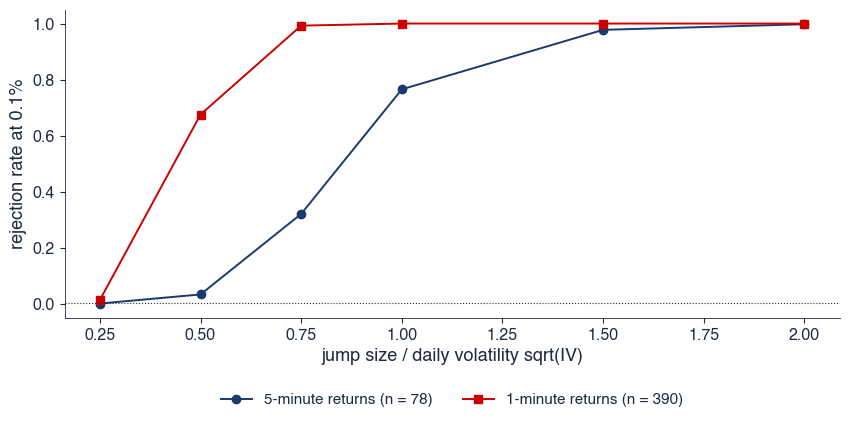

{'crit': 3.090232306167813, 'days': 400, 'size_clean_5m': 0.0, 'size_clean_1m': 0.0025, 'size_clean_5s': 0.0, 'size_noisy_5m': 0.0, 'size_noisy_1m': 0.0, 'size_noisy_5s': 0.0, 'sizes': [0.25, 0.5, 0.75, 1.0, 1.5, 2.0], 'power': {'5m': [0.0, 0.0325, 0.32, 0.765, 0.9775, 0.9975], '1m': [0.0125, 0.675, 0.9925, 1.0, 1.0, 1.0]}}


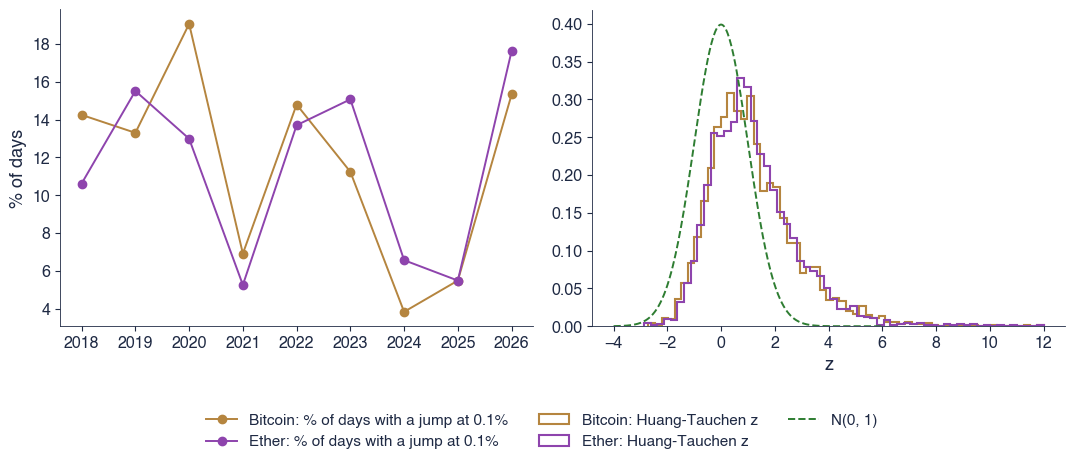

{'btc': {'T': 3165, 'share': 0.11437598736176935, 'n_jump': 362, 'expected_false': 3.165, 'jv_share': 0.02966282232033407, 'mean_z': 1.1642860761087586, 'first': '2018-01-02', 'last': '2026-09-18', 'rv_bv': 0.0813417597159953}, 'eth': {'T': 3165, 'share': 0.11216429699842022, 'n_jump': 355, 'expected_false': 3.165, 'jv_share': 0.023206751102458578, 'mean_z': 1.1855549973010453, 'first': '2018-01-02', 'last': '2026-09-18', 'rv_bv': 0.07144743070578588}}


In [10]:
def fig_jump_sim(save_it=True, days=2000):
    """Size and power of the Huang-Tauchen test at 0.1% (one-sided), 5-minute and 1-minute returns, with and
    without noise; power as a function of the jump size (in units of the daily volatility)."""
    rng = np.random.default_rng(SEED + 3)
    p = dict(SIM, n=390 * 60)
    X, Y, iv, qv = simulate_intraday(days, rng, p, jumps=False)
    crit = stats.norm.ppf(0.999)
    out = {'crit': float(crit), 'days': days}
    for lab, P in (('clean', X), ('noisy', Y)):
        for k, nm in ((300, '5m'), (60, '1m'), (5, '5s')):
            r = np.diff(P[:, ::k], axis=1)
            z = ht_stat((r ** 2).sum(1), bipower(r), tripower(r), r.shape[1])
            out[f'size_{lab}_{nm}'] = float(np.mean(z > crit))
    sizes = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
    pw = {'5m': [], '1m': []}
    pos = rng.integers(0, X.shape[1] - 1, days)
    sg = np.sign(rng.standard_normal(days))
    for s in sizes:
        Xj = X.copy()
        for d in range(days):
            Xj[d, pos[d] + 1:] += s * sg[d] * np.sqrt(iv[d])
        for k, nm in ((300, '5m'), (60, '1m')):
            r = np.diff(Xj[:, ::k], axis=1)
            z = ht_stat((r ** 2).sum(1), bipower(r), tripower(r), r.shape[1])
            pw[nm].append(float(np.mean(z > crit)))
    out['sizes'] = sizes
    out['power'] = pw
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(sizes, pw['5m'], 'o-', color=st.MainBlue, label='5-minute returns (n = 78)')
    ax.plot(sizes, pw['1m'], 's-', color=st.IDAred, label='1-minute returns (n = 390)')
    ax.axhline(0.001, color=st.DarkText, lw=0.8, ls=':')
    ax.set_xlabel('jump size / daily volatility sqrt(IV)')
    ax.set_ylabel('rejection rate at 0.1%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch8_jump_power', save_it)
    return out


def fig_jumps_crypto(save_it=True):
    """Jump days of Bitcoin and Ether (5-minute returns, n = 288), share by year; jump share of total variation."""
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    for coin, c, lab in (('btc', st.COL['btc'], 'Bitcoin'), ('eth', st.Purple, 'Ether')):
        d = binance_daily(coin)
        z, j = jump_days(d, 288)
        jv = np.where(j, np.maximum(d['rv5'] - d['bv5'], 0), 0)
        share = pd.Series(j.values, d.index).groupby(d.index.year).mean()
        axes[0].plot(share.index, 100 * share.values, 'o-', color=c, label=f'{lab}: % of days with a jump at 0.1%')
        axes[1].hist(np.clip(z, -6, 12), bins=60, density=True, histtype='step', color=c, lw=1.5, label=f'{lab}: Huang-Tauchen z')
        out[coin] = dict(T=len(d), share=float(j.mean()), n_jump=int(j.sum()), expected_false=float(0.001 * len(d)),
                         jv_share=float(jv.sum() / d['rv5'].sum()), mean_z=float(z.mean()),
                         first=str(d.index[0].date()), last=str(d.index[-1].date()),
                         rv_bv=float(np.mean(np.maximum(d['rv5'] - d['bv5'], 0)) / d['rv5'].mean()))
    g = np.linspace(-4, 6, 300)
    axes[1].plot(g, stats.norm.pdf(g), color=st.Forest, ls='--', label='N(0, 1)')
    axes[0].set_ylabel('% of days')
    axes[1].set_xlabel('z')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('ats_ch8_jumps_crypto', save_it)
    return out


print(fig_jump_sim(save_it=False, days=400))
print(fig_jumps_crypto(save_it=False))

## 6. HAR, HAR-CJ, log-HAR and HARQ

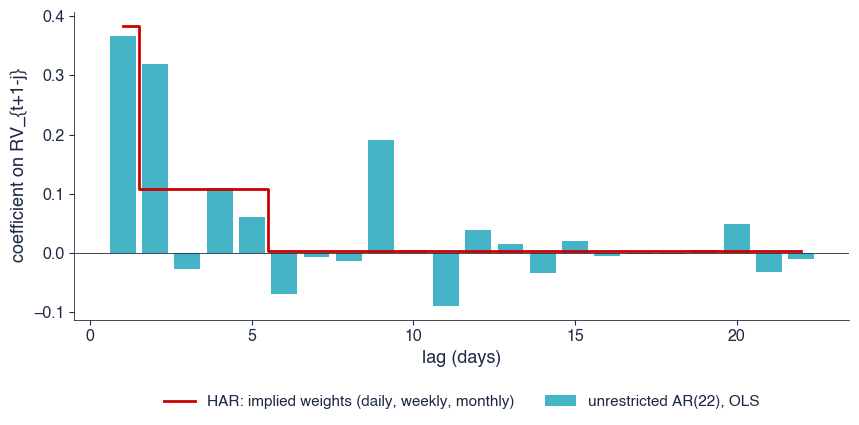

[0.11866816552370714, 0.27518268685428715, 0.521869698853872, 0.0940277625677296]


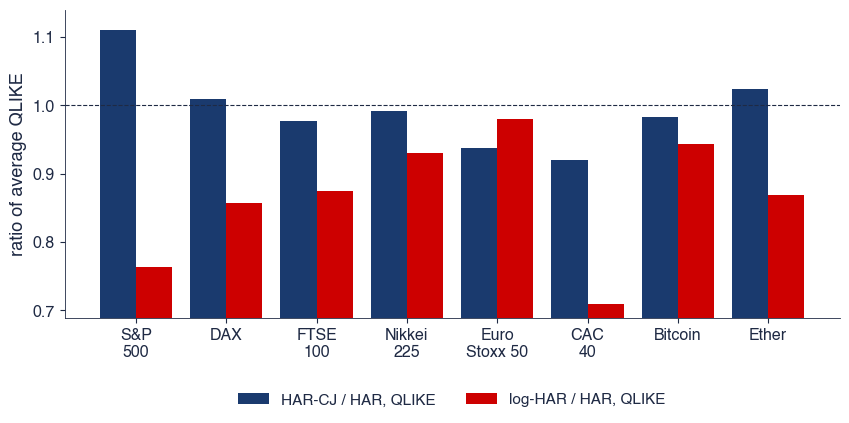

{'.SPX': {'harcj': 1.1101988906890383, 'loghar': 0.7638279362209194}, '.GDAXI': {'harcj': 1.008635078972894, 'loghar': 0.8575176404310898}, '.FTSE': {'harcj': 0.9762304358959707, 'loghar': 0.8741896177213487}, '.N225': {'harcj': 0.9911823008365319, 'loghar': 0.9302030465846877}, '.STOXX50E': {'harcj': 0.937720632193082, 'loghar': 0.9805474690661796}, '.FCHI': {'harcj': 0.9198333601058971, 'loghar': 0.7090878549455599}, 'btc': {'harcj': 0.9828459852674222, 'loghar': 0.943233814663157, 'harq': 0.9456784483334987}, 'eth': {'harcj': 1.0243942160505284, 'loghar': 0.8689957462243559, 'harq': 0.9207777976602349}}


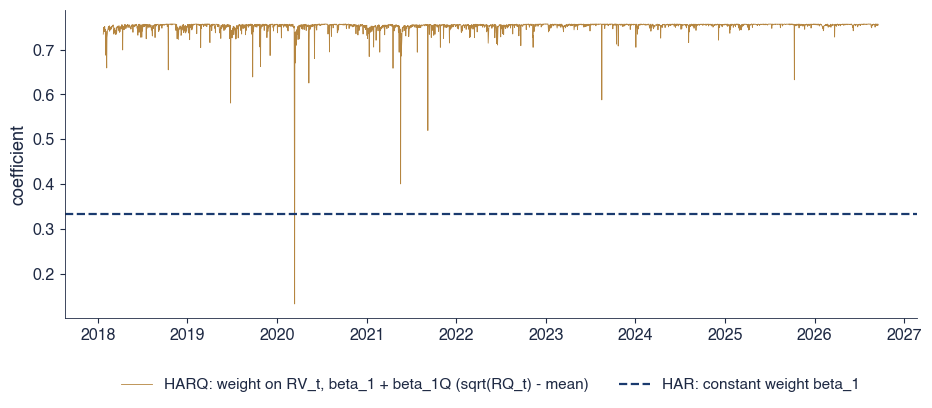

{'T': 3143, 'b': [1.952132259869027, 0.7517864178941784, -0.00020858360752220025, 0.05236011791449465, 0.07671875391717481], 'se': [0.7845225516119382, 0.2963680817569054, 7.628519274700197e-05, 0.12637332508687474, 0.09401782037265335], 'bh': [3.5000141923727623, 0.33386124289948016, 0.1763047656095738, 0.20307465207976216], 'seh': [0.8052725095716845, 0.11594090648679913, 0.09058968404198699, 0.07300683143631445], 'q01': 0.7069728542789622, 'q50': 0.7552507293025613, 'q99': 0.7572283223099553, 'wmin': 0.13294564973248402, 'share_neg': 0.0, 'first': '2018-01-23', 'last': '2026-09-17'}


In [11]:
def fig_har_insample(save_it=True, L=5):
    """HAR-RV of Corsi (2009) for the S&P 500 (OMI, 5-minute RV): OLS with Newey-West s.e., the implied lag weights
    against an unrestricted AR(22); the same in logs."""
    d = omi('.SPX')
    rv = d['rv']
    X = har_X(rv)
    y = rv.shift(-1)
    D = pd.concat([y.rename('y'), X], axis=1).dropna()
    Xm = np.column_stack([np.ones(len(D)), D[['d', 'w', 'm']].values])
    b, u = ols(D['y'].values, Xm)
    se = newey_west(Xm, u, L)
    r2 = 1 - u.var() / D['y'].var()
    lags = pd.concat([rv.shift(j).rename(j) for j in range(22)], axis=1)
    D2 = pd.concat([y.rename('y'), lags], axis=1).dropna()
    b22, u22 = ols(D2['y'].values, np.column_stack([np.ones(len(D2)), D2.drop(columns='y').values]))
    imp = np.array([b[1] + b[2] / 5 + b[3] / 22 if j == 0 else (b[2] / 5 + b[3] / 22 if j < 5 else b[3] / 22) for j in range(22)])
    # Wald test of the 19 HAR restrictions on the AR(22), Newey-West
    Xa = np.column_stack([np.ones(len(D2)), D2.drop(columns='y').values])
    se22 = newey_west(Xa, u22, L)
    lv = np.log(rv)
    Xl = har_X(lv)
    Dl = pd.concat([lv.shift(-1).rename('y'), Xl], axis=1).dropna()
    Xlm = np.column_stack([np.ones(len(Dl)), Dl[['d', 'w', 'm']].values])
    bl, ul = ols(Dl['y'].values, Xlm)
    sel = newey_west(Xlm, ul, L)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    j = np.arange(1, 23)
    ax.bar(j, b22[1:], color=st.Teal, alpha=0.8, label='unrestricted AR(22), OLS')
    ax.step(j, imp, where='mid', color=st.IDAred, lw=2, label='HAR: implied weights (daily, weekly, monthly)')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel('lag (days)')
    ax.set_ylabel('coefficient on RV_{t+1-j}')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch8_har_weights', save_it)
    return dict(T=len(D), b=b.tolist(), se=se.tolist(), r2=float(r2), sum=float(b[1:].sum()), b22=b22.tolist(),
                r2_22=float(1 - u22.var() / D2['y'].var()), bl=bl.tolist(), sel=sel.tolist(),
                r2l=float(1 - ul.var() / Dl['y'].var()), suml=float(bl[1:].sum()),
                first=str(D.index[0].date()), last=str(D.index[-1].date()))


def fig_har_oos(save_it=True):
    """Out-of-sample HAR, HAR-CJ and log-HAR on six OMI indices; HAR, log-HAR and HARQ on Bitcoin and Ether."""
    out = {}
    rows = []
    for sym in OMI_NAMES:
        d = omi(sym)
        f = har_forecasts(d[['rv', 'bv']], ['har', 'harcj', 'loghar'])
        res = {}
        for m in ('harcj', 'loghar'):
            res[m] = dict(qlike=float(qlike(f['y'], f[m]).mean() / qlike(f['y'], f['har']).mean()),
                          mse=float(((f['y'] - f[m]) ** 2).mean() / ((f['y'] - f['har']) ** 2).mean()),
                          dm=dm_test(qlike(f['y'], f[m]), qlike(f['y'], f['har'])))
        res['har_qlike'] = float(qlike(f['y'], f['har']).mean())
        res['T'] = len(f)
        out[sym] = res
        rows.append((OMI_NAMES[sym], res['harcj']['qlike'], res['loghar']['qlike']))
    for coin in ('btc', 'eth'):
        d = binance_daily(coin)
        dd = pd.DataFrame({'rv': d['rv5'], 'bv': d['bv5'], 'rq': d['rq5']})
        f = har_forecasts(dd, ['har', 'harcj', 'loghar', 'harq'])
        res = {}
        for m in ('harcj', 'loghar', 'harq'):
            res[m] = dict(qlike=float(qlike(f['y'], f[m]).mean() / qlike(f['y'], f['har']).mean()),
                          mse=float(((f['y'] - f[m]) ** 2).mean() / ((f['y'] - f['har']) ** 2).mean()),
                          dm=dm_test(qlike(f['y'], f[m]), qlike(f['y'], f['har'])))
        res['T'] = len(f)
        res['first'] = str(f.index[0].date())
        out[coin] = res
        rows.append((('Bitcoin' if coin == 'btc' else 'Ether'), res['harcj']['qlike'], res['loghar']['qlike']))
    fig, ax = plt.subplots(figsize=(10, 4.0))
    x = np.arange(len(rows))
    ax.bar(x - 0.2, [r[1] for r in rows], 0.4, color=st.MainBlue, label='HAR-CJ / HAR, QLIKE')
    ax.bar(x + 0.2, [r[2] for r in rows], 0.4, color=st.IDAred, label='log-HAR / HAR, QLIKE')
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([r[0].replace(' ', '\n', 1) for r in rows])
    ax.set_ylabel('ratio of average QLIKE')
    lo = min(min(r[1], r[2]) for r in rows)
    hi = max(max(r[1], r[2]) for r in rows)
    ax.set_ylim(min(0.8, lo - 0.02), max(1.08, hi + 0.03))
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch8_har_oos', save_it)
    return out


def fig_harq(save_it=True):
    """HARQ of Bollerslev, Patton and Quaedvlieg (2016) for Bitcoin: full-sample estimates and the time-varying
    weight on yesterday's RV, beta_1 + beta_1Q sqrt(RQ_t); out-of-sample gains."""
    d = binance_daily('btc')
    rv, rq = d['rv5'], d['rq5']
    sq = np.sqrt(rq) - np.sqrt(rq).mean()          # demeaned: beta_1 is the weight on a day of average precision
    X = har_X(rv, {'dq': rv * sq})
    D = pd.concat([rv.shift(-1).rename('y'), X], axis=1).dropna()
    A = np.column_stack([np.ones(len(D)), D[['d', 'dq', 'w', 'm']].values])
    b, u = ols(D['y'].values, A)
    se = newey_west(A, u, 5)
    Ah = np.column_stack([np.ones(len(D)), D[['d', 'w', 'm']].values])
    bh, uh = ols(D['y'].values, Ah)
    seh = newey_west(Ah, uh, 5)
    wt = b[1] + b[2] * sq.reindex(D.index)
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ax.plot(D.index, wt, color=st.COL['btc'], lw=0.6, label='HARQ: weight on RV_t, beta_1 + beta_1Q (sqrt(RQ_t) - mean)')
    ax.axhline(bh[1], color=st.MainBlue, lw=1.6, ls='--', label='HAR: constant weight beta_1')
    ax.set_ylabel('coefficient')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch8_harq', save_it)
    return dict(T=len(D), b=b.tolist(), se=se.tolist(), bh=bh.tolist(), seh=seh.tolist(),
                q01=float(np.quantile(wt, 0.01)), q50=float(np.median(wt)), q99=float(np.quantile(wt, 0.99)),
                wmin=float(wt.min()), share_neg=float(np.mean(wt < 0)), first=str(D.index[0].date()), last=str(D.index[-1].date()))


print(fig_har_insample(save_it=False)['b'])
r = fig_har_oos(save_it=False)
print({k: {m: v[m]['qlike'] for m in v if isinstance(v[m], dict)} for k, v in r.items()})
print(fig_harq(save_it=False))

## 7. Realized GARCH and HEAVY for the S&P 500

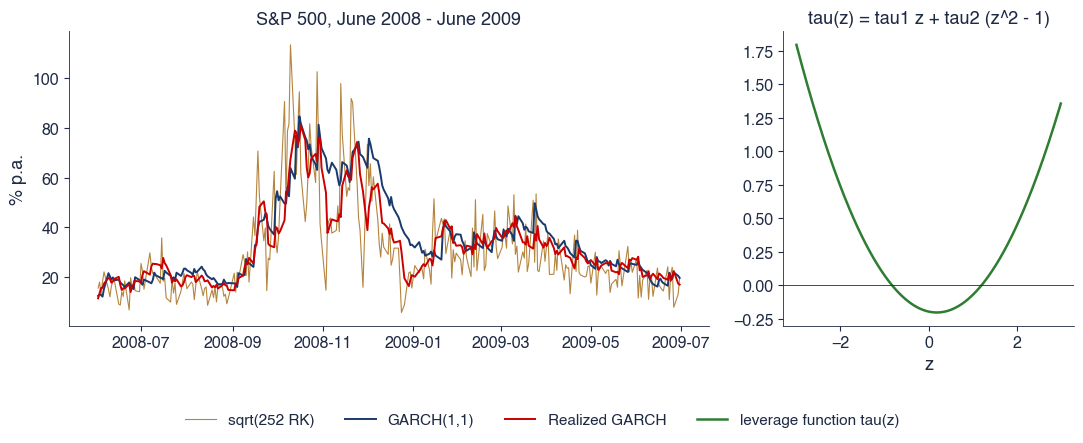

{'T': 5552, 'theta': [0.11928973680787248, 0.6777205343189696, 0.28685987140652675, -0.45556805531075234, 1.0116599915464528, -0.0730716313521164, 0.19697825291513849, 0.671301924080071], 'se': [0.01026690781208027, 0.018358515872130738, 0.016005310386470094, 0.020701571924806324, 0.025952067016626168, 0.0075669388988692295, 0.010229846931914892, 0.007680380184517735], 'll': np.float64(-12564.99496668482), 'll_r': -6899.721663807768, 'll_garch': np.float64(-7099.025607992695), 'll_gjr': np.float64(-6998.79873432916), 'll_heavy': np.float64(-6902.807754603326), 'heavy': [0.00873719652942204, 0.37734236292914214, 0.6906775137325096], 'pers': 0.9679251894011129, 'garch': [0.015497510647480402, 0.11988104618883588, 0.8687404418078866], 'gjr': [0.020295130033736855, 0.008142320733251216, 0.8849243321727429, 0.17040393520501673], 'first': '2000-01-03', 'last': '2022-02-25'}


In [12]:
def fig_rgarch(save_it=True):
    """Realized GARCH, HEAVY and GARCH(1,1) for S&P 500 open-to-close returns with the realised kernel (OMI)."""
    d = omi('.SPX')
    r = (d['oc'] - d['oc'].mean()).values
    x = d['rk'].values
    rg = fit_rgarch(r, x)
    g = fit_garch(r, se=False)
    gj = fit_garch(r, gjr=True, se=False)
    hv = fit_heavy(r, x)
    th = rg['theta']
    pers = th[1] + th[4] * th[2]
    idx = d.index
    sl = (idx >= '2008-06-01') & (idx <= '2009-06-30')
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw=dict(width_ratios=[2.2, 1]))
    ax = axes[0]
    ann = np.sqrt(252)
    ax.plot(idx[sl], ann * np.sqrt(x[sl]), color=st.Amber, lw=0.8, label='sqrt(252 RK)')
    ax.plot(idx[sl], ann * np.sqrt(g['s'][sl]), color=st.MainBlue, lw=1.4, label='GARCH(1,1)')
    ax.plot(idx[sl], ann * np.sqrt(rg['h'][sl]), color=st.IDAred, lw=1.4, label='Realized GARCH')
    ax.set_ylabel('% p.a.')
    ax.set_title('S&P 500, June 2008 - June 2009')
    ax = axes[1]
    zz = np.linspace(-3, 3, 200)
    ax.plot(zz, th[5] * zz + th[6] * (zz ** 2 - 1), color=st.Forest, lw=1.8, label='leverage function tau(z)')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel('z')
    ax.set_title('tau(z) = tau1 z + tau2 (z^2 - 1)')
    st.fig_legend_bottom(fig, ncol=4, y=-0.02)
    plt.tight_layout()
    save('ats_ch8_rgarch', save_it)
    return dict(T=len(r), theta=th.tolist(), se=rg['se_bw'].tolist(), ll=rg['ll'], ll_r=rg['ll_r'], ll_garch=g['ll'],
                ll_gjr=gj['ll'], ll_heavy=hv['ll'], heavy=hv['theta'].tolist(), pers=float(pers),
                garch=g['theta'].tolist(), gjr=gj['theta'].tolist(), first=str(idx[0].date()), last=str(idx[-1].date()))


print(fig_rgarch(save_it=False))

## 8. Robust losses and the out-of-sample comparison

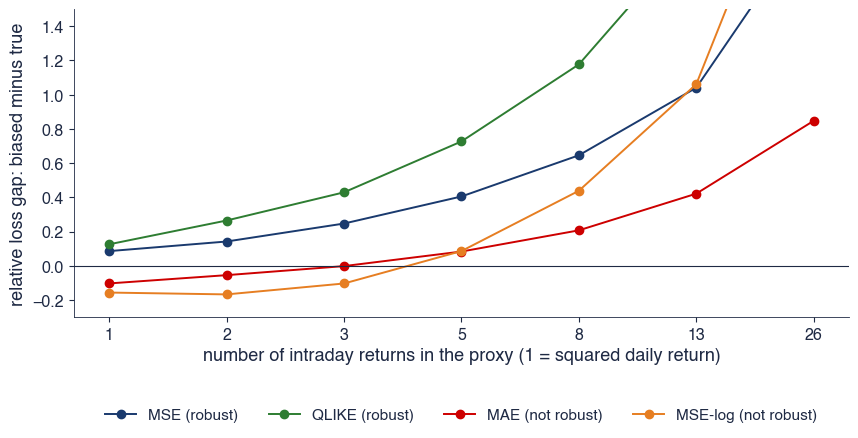

{'n': [1, 2, 3, 5, 8, 13, 26], 'c': 0.6, 'MSE': [0.08587493029296439, 0.14197028934180375, 0.24697037542475522, 0.4051501678809414, 0.6457294315899937, 1.0406864720351883, 2.0447260431099976], 'QLIKE': [0.12564599376087365, 0.26465856486403244, 0.42938548115659175, 0.7267234617855435, 1.1768163966551255, 1.9622529658142105, 3.9796773737625646], 'MAE': [-0.10299691938145415, -0.05465883072900367, -0.00172634101512766, 0.08331180816919923, 0.20727027886872168, 0.4215800982526229, 0.8473569292020949], 'MSE-log': [-0.1563388021981656, -0.16712006058060117, -0.10337848883268065, 0.0859874034667109, 0.4383022121169643, 1.060984165735603, 2.780719246843959], 'c_opt_mselog_n1': 0.28072974178344257}


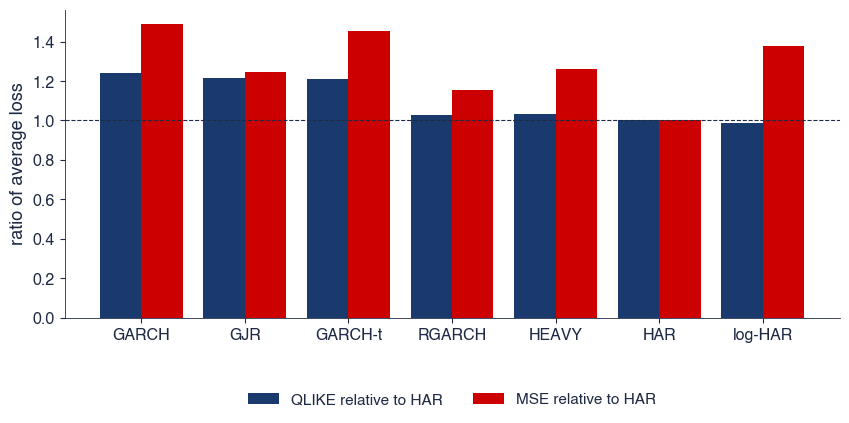

{'GARCH': {'qlike': 0.4073859033506361, 'mse': 2.3775641445721236, 'dm_q': 8.623891356648468, 'dm_m': 1.3678941296356002}, 'GJR': {'qlike': 0.39822744755948836, 'mse': 1.9911531684084793, 'dm_q': 6.271804336890522, 'dm_m': 1.1132273924872342}, 'GARCH-t': {'qlike': 0.3964763980438743, 'mse': 2.3260347131045065, 'dm_q': 6.6889941493197655, 'dm_m': 1.529587289947595}, 'RGARCH': {'qlike': 0.3369944828858865, 'mse': 1.8443506234850184, 'dm_q': 1.4249984142407668, 'dm_m': 1.5390262971504372}, 'HEAVY': {'qlike': 0.3389503231254578, 'mse': 2.0184888175163134, 'dm_q': 2.1733057900987767, 'dm_m': 0.9209399056876446}, 'HAR': {'qlike': 0.32797364536567253, 'mse': 1.5974022211996688, 'dm_q': 0.0, 'dm_m': 0.0}, 'log-HAR': {'qlike': 0.32381302998885786, 'mse': 2.2048715899171034, 'dm_q': -0.3721055839208245, 'dm_m': 1.189980301027666}}


In [13]:
def loss(kind, proxy, f):
    if kind == 'MSE':
        return (proxy - f) ** 2
    if kind == 'QLIKE':
        return proxy / f - np.log(proxy / f) - 1
    if kind == 'MAE':
        return np.abs(proxy - f)
    if kind == 'MSE-log':
        return (np.log(proxy) - np.log(f)) ** 2
    raise KeyError(kind)


def fig_patton(save_it=True, T=200000, c=0.6):
    """Patton (2011): expected loss of the true variance and of a forecast biased downwards by the factor c, when
    the proxy is RV with n intraday returns (n = 1: the squared daily return). Positive = the true variance wins."""
    rng = np.random.default_rng(SEED + 4)
    ns = [1, 2, 3, 5, 8, 13, 26]
    sig2 = np.exp(rng.normal(0, 0.8, T))
    out = {'n': ns, 'c': c}
    fig, ax = plt.subplots(figsize=(10, 4.0))
    cols = {'MSE': st.MainBlue, 'QLIKE': st.Forest, 'MAE': st.IDAred, 'MSE-log': st.Orange}
    for kind in cols:
        diff = []
        for n in ns:
            proxy = sig2 * rng.chisquare(n, T) / n
            l_true = loss(kind, proxy, sig2).mean()
            l_bias = loss(kind, proxy, c * sig2).mean()
            diff.append(float((l_bias - l_true) / l_true))
        out[kind] = diff
        ax.plot(range(len(ns)), diff, 'o-', color=cols[kind], label=kind + (' (robust)' if kind in ('MSE', 'QLIKE') else ' (not robust)'))
    ax.axhline(0, color=st.DarkText, lw=0.8)
    ax.set_xticks(range(len(ns)))
    ax.set_xticklabels([str(n) for n in ns])
    ax.set_xlabel('number of intraday returns in the proxy (1 = squared daily return)')
    ax.set_ylabel('relative loss gap: biased minus true')
    ax.set_ylim(-0.3, 1.5)
    st.legend_outside_bottom(ax, ncol=4, y=-0.25)
    save('ats_ch8_patton', save_it)
    out['c_opt_mselog_n1'] = float(np.exp(special.digamma(0.5) + np.log(2)))
    return out


def fig_vol_oos(save_it=True, start_oos='2016-01-01', refit=250):
    """S&P 500 (OMI): one-day-ahead forecasts of the open-to-close variance from GARCH, GJR, GARCH-t, Realized GARCH,
    HEAVY, HAR and log-HAR (on RK), expanding window from 2000, parameters re-estimated every 250 days; evaluated
    against the realised kernel with QLIKE and MSE; Diebold-Mariano against HAR."""
    d = omi('.SPX')
    r_all = (d['oc'] - d['oc'].mean()).values
    x_all = d['rk'].values
    idx = d.index
    t0 = int(np.searchsorted(idx, pd.Timestamp(start_oos)))
    T = len(idx)
    F = {k: np.full(T, np.nan) for k in ('GARCH', 'GJR', 'GARCH-t', 'RGARCH', 'HEAVY', 'HAR', 'log-HAR')}
    hx = har_X(pd.Series(x_all, idx))
    lhx = har_X(pd.Series(np.log(x_all), idx))
    for s in range(t0, T, refit):
        e = min(s + refit, T)
        r_est, x_est = r_all[:s], x_all[:s]
        # GARCH family: filter through the whole sample with parameters from the estimation window
        for nm, kw in (('GARCH', {}), ('GJR', dict(gjr=True)), ('GARCH-t', dict(dist='t'))):
            th = fit_garch(r_est, se=False, **kw)['theta']
            sv = garch_var(np.r_[r_all[:e], 0.0], th[0], th[1], th[2], th[3] if kw.get('gjr') else 0.0, s0=np.var(r_est))
            F[nm][s:e] = sv[s:e]
        rg = fit_rgarch(r_est, x_est, se=False)
        lh = rgarch_paths(rg['theta'], r_all[:e], x_all[:e])
        F['RGARCH'][s:e] = np.exp(lh[s:e])
        hv = fit_heavy(r_est, x_est)
        F['HEAVY'][s:e] = heavy_var(x_all[:e], *hv['theta'], np.var(r_est))[s:e]
        for nm, XX, lg in (('HAR', hx, False), ('log-HAR', lhx, True)):
            y = (np.log(x_all) if lg else x_all)
            ok = np.arange(22, s - 1)
            A = np.column_stack([np.ones(len(ok)), XX.values[ok]])
            b, u = ols(y[ok + 1], A)
            pred = np.column_stack([np.ones(e - s), XX.values[s - 1:e - 1]]) @ b
            F[nm][s:e] = np.exp(pred + 0.5 * u.var()) if lg else pred
    sl = slice(t0, T)
    y = x_all[sl]
    out = {'T_oos': T - t0, 'first': str(idx[t0].date()), 'last': str(idx[-1].date())}
    res = {}
    for k, f in F.items():
        f = np.maximum(f[sl], 1e-4)
        res[k] = dict(qlike=float(loss('QLIKE', y, f).mean()), mse=float(loss('MSE', y, f).mean()))
    fh = np.maximum(F['HAR'][sl], 1e-4)
    for k, f in F.items():
        f = np.maximum(f[sl], 1e-4)
        res[k]['dm_q'] = dm_test(loss('QLIKE', y, f), loss('QLIKE', y, fh)) if k != 'HAR' else 0.0
        res[k]['dm_m'] = dm_test(loss('MSE', y, f), loss('MSE', y, fh)) if k != 'HAR' else 0.0
    out['res'] = res
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ks = list(F)
    x = np.arange(len(ks))
    q = np.array([res[k]['qlike'] for k in ks]) / res['HAR']['qlike']
    m = np.array([res[k]['mse'] for k in ks]) / res['HAR']['mse']
    ax.bar(x - 0.2, q, 0.4, color=st.MainBlue, label='QLIKE relative to HAR')
    ax.bar(x + 0.2, m, 0.4, color=st.IDAred, label='MSE relative to HAR')
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(ks)
    ax.set_ylabel('ratio of average loss')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch8_vol_oos', save_it)
    return out


print(fig_patton(save_it=False, T=50000))
print(fig_vol_oos(save_it=False)['res'])

## 9. DCC against cDCC; GMV portfolios with DCC-NL; realised correlation

{'vec': 211575, 'bekk': 1575, 'dbekk': 375, 'sbekk': 327, 'dcc': 377}


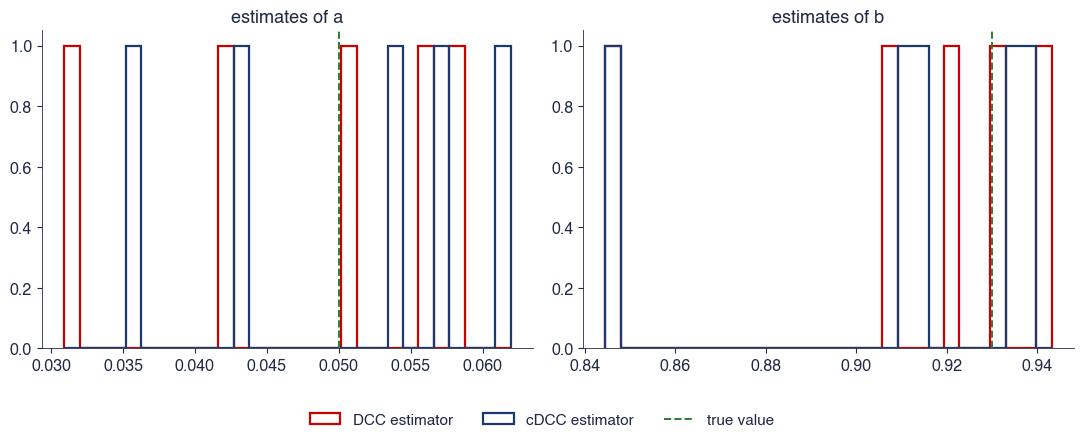

{'reps': 5, 'T': 1000, 'a': 0.05, 'b': 0.93, 'rho': 0.5, 'mean': {'DCC': [0.047620857987320867, 0.9095512652832426], 'cDCC': [0.05047803469024683, 0.9085527400161503]}, 'sd': {'DCC': [0.009972895255808351, 0.033770520994522726], 'cDCC': [0.009497705746834957, 0.03362429891559068]}, 'rmse': {'DCC': [0.010252753605730495, 0.039479093704869], 'cDCC': [0.009509728262076743, 0.03988205659666802]}}


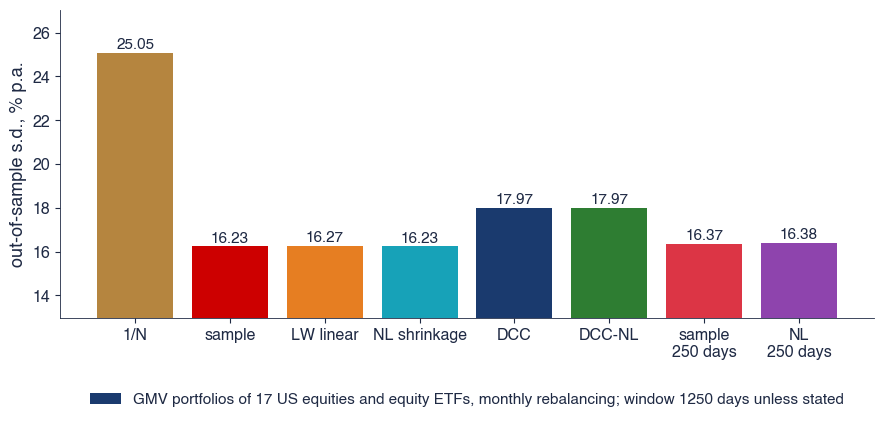

{'1/N': 25.047853781639752, 'sample': 16.23267282555277, 'LW linear': 16.274898026721253, 'NL shrinkage': 16.231086275899766, 'DCC': 17.971432526158978, 'DCC-NL': 17.97321419822622, 'sample, short': 16.366321425883694, 'NL, short': 16.383203784671927}


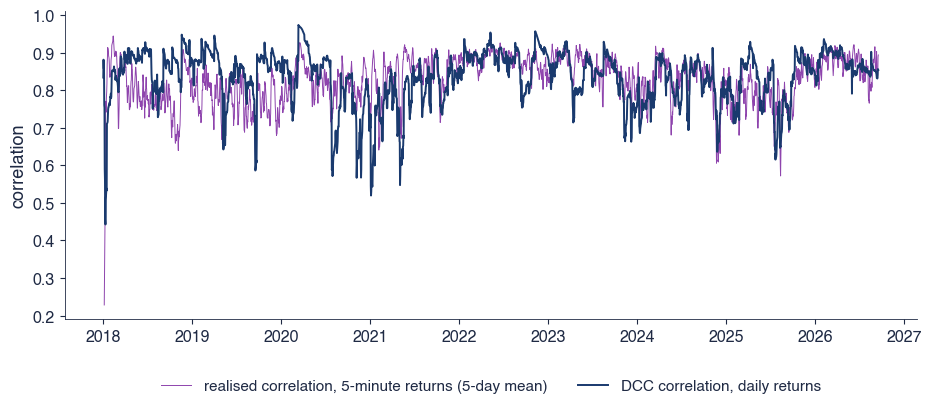

{'T': 3165, 'a': 0.05070232680911939, 'b': 0.9283334635260527, 'rc_mean': 0.826057438884621, 'dcc_mean': 0.8340465424174529, 'corr_rc_dcc': 0.2619061379050711, 'rc_q05': 0.677833916959022, 'first': '2018-01-02', 'last': '2026-09-18'}


In [14]:
def fig_dcc_sim(save_it=True, reps=100, T=2000, a=0.05, b=0.93, rho=0.5):
    """Aielli (2013): DCC and cDCC estimators of (a, b) on data simulated from a cDCC model (bivariate, unit variances)."""
    rng = np.random.default_rng(SEED + 5)
    est = {'DCC': [], 'cDCC': []}
    for _ in range(reps):
        Z = simulate_cdcc(T, a, b, rho, rng)
        est['DCC'].append(fit_dcc(Z)[0])
        est['cDCC'].append(fit_dcc(Z, corrected=True)[0])
    est = {k: np.array(v) for k, v in est.items()}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
    for ax, j, nm, tv in zip(axes, (0, 1), ('a', 'b'), (a, b)):
        bins = np.linspace(min(est['DCC'][:, j].min(), est['cDCC'][:, j].min()),
                           max(est['DCC'][:, j].max(), est['cDCC'][:, j].max()), 30)
        ax.hist(est['DCC'][:, j], bins=bins, histtype='step', lw=1.6, color=st.IDAred, label='DCC estimator')
        ax.hist(est['cDCC'][:, j], bins=bins, histtype='step', lw=1.6, color=st.MainBlue, label='cDCC estimator')
        ax.axvline(tv, color=st.Forest, ls='--', lw=1.4, label='true value')
        ax.set_title(f'estimates of {nm}')
    st.fig_legend_bottom(fig, ncol=3, y=-0.02)
    plt.tight_layout()
    save('ats_ch8_dcc_sim', save_it)
    return dict(reps=reps, T=T, a=a, b=b, rho=rho,
                mean={k: v.mean(0).tolist() for k, v in est.items()}, sd={k: v.std(0).tolist() for k, v in est.items()},
                rmse={k: np.sqrt(((v - np.array([a, b])) ** 2).mean(0)).tolist() for k, v in est.items()})


def fig_gmv(save_it=True, win=1250, short=250, hold=21, start='2012-06-01'):
    """Out-of-sample global minimum-variance portfolios of 14 US stocks and 3 equity ETFs: sample covariance,
    Ledoit-Wolf linear and nonlinear shrinkage of the correlation matrix, DCC and DCC-NL (Engle, Ledoit and Wolf
    2019), 1/N; monthly rebalancing with DCC forecasts averaged over the 21-day holding period; the static
    estimators also with a short window (larger N/T)."""
    P = pd.concat([read_market(s)['adjusted_close'].rename(s) for s in GMV_ASSETS], axis=1).loc[start:]
    P = P[P.index.dayofweek < 5].dropna()
    R = (100 * np.log(P).diff()).dropna()
    Rv = R.values
    T, N = Rv.shape
    methods = ['1/N', 'sample', 'LW linear', 'NL shrinkage', 'DCC', 'DCC-NL', 'sample, short', 'NL, short']
    port = {m: [] for m in methods}
    ab = {'DCC': [], 'DCC-NL': []}
    conds = []
    dates = []
    for s in range(win, T - 1, hold):
        X = Rv[s - win:s]
        Xc = X - X.mean(0)
        Xs = Rv[s - short:s]
        e_ = min(s + hold, T)
        S_ = Xc.T @ Xc / win
        conds.append(np.linalg.cond(np.corrcoef(Xc.T)))
        Sig = {'sample': S_, 'LW linear': corr_shrunk(X, 'lw'), 'NL shrinkage': corr_shrunk(X, 'nl'),
               'sample, short': np.cov(Xs.T), 'NL, short': corr_shrunk(Xs, 'nl')}
        Z, nxt = garch_univariate_std(Xc, hold)
        Dn = np.sqrt(nxt)
        for nm in ('DCC', 'DCC-NL'):
            if nm == 'DCC':
                tgt = np.corrcoef(Z.T)
            else:
                C = nl_shrink(Z - Z.mean(0))
                dd = np.sqrt(np.diag(C))
                tgt = C / np.outer(dd, dd)
            (a, b), _ = fit_dcc(Z, tgt)
            ab[nm].append((a, b))
            Q = tgt.copy()
            for t in range(win):
                Q = (1 - a - b) * tgt + a * np.outer(Z[t], Z[t]) + b * Q
            Q = tgt + (Q - tgt) * np.mean((a + b) ** np.arange(hold))   # average forecast over the holding period
            dq = np.sqrt(np.diag(Q))
            Sig[nm] = np.outer(Dn, Dn) * Q / np.outer(dq, dq)
        W = {m: gmv(Sig[m]) for m in Sig}
        W['1/N'] = np.ones(N) / N
        for m in methods:
            port[m].append(Rv[s:e_] @ W[m])
        dates.append(R.index[s])
    out = {'N': N, 'T': T, 'first_oos': str(R.index[win].date()), 'last': str(R.index[-1].date()), 'n_rebal': len(dates),
           'win': win, 'short': short, 'first': str(R.index[0].date()), 'cond_med': float(np.median(conds))}
    sd = {m: float(np.sqrt(252) * np.concatenate(port[m]).std()) for m in methods}
    out['sd'] = sd
    out['ab'] = {k: np.mean(v, 0).tolist() for k, v in ab.items()}
    fig, ax = plt.subplots(figsize=(10.5, 4.0))
    x = np.arange(len(methods))
    cols = [st.Amber, st.IDAred, st.Orange, st.Teal, st.MainBlue, st.Forest, st.Crimson, st.Purple]
    ax.bar(x, [sd[m] for m in methods], color=cols)
    for i, m in enumerate(methods):
        ax.text(i, sd[m] + 0.2, f'{sd[m]:.2f}', ha='center', color=st.DarkText, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(', short', f'\n{short} days') for m in methods])
    ax.set_ylabel('out-of-sample s.d., % p.a.')
    ax.set_ylim(min(sd.values()) * 0.8, max(sd.values()) * 1.08)
    ax.bar([0], [0], color=st.MainBlue, label=f'GMV portfolios of {N} US equities and equity ETFs, monthly rebalancing; window {win} days unless stated')
    st.legend_outside_bottom(ax, ncol=1, y=-0.2)
    save('ats_ch8_gmv', save_it)
    return out


def fig_corr_crypto(save_it=True):
    """Daily realised correlation of Bitcoin and Ether (5-minute returns) against the DCC correlation of daily returns."""
    b = binance_daily('btc')
    e = binance_daily('eth')
    D = pd.concat([b['ret'].rename('b'), e['ret'].rename('e'), b['rv5'].rename('vb'), e['rv5'].rename('ve'),
                   b['rcov5'].rename('c')], axis=1).dropna()
    rc = D['c'] / np.sqrt(D['vb'] * D['ve'])
    Rr = D[['b', 'e']].values
    Rr = Rr - Rr.mean(0)
    Z, _ = garch_univariate_std(Rr)
    (a, bb), _ = fit_dcc(Z)
    _, Rs = dcc_loglik((a, bb), Z, np.corrcoef(Z.T), return_R=True)
    dcc = np.array([R[0, 1] for R in Rs])
    fig, ax = plt.subplots(figsize=(11, 4.0))
    ax.plot(D.index, rc.rolling(5).mean(), color=st.Purple, lw=0.7, label='realised correlation, 5-minute returns (5-day mean)')
    ax.plot(D.index, dcc, color=st.MainBlue, lw=1.4, label='DCC correlation, daily returns')
    ax.set_ylabel('correlation')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ats_ch8_corr_crypto', save_it)
    return dict(T=len(D), a=float(a), b=float(bb), rc_mean=float(rc.mean()), dcc_mean=float(dcc.mean()),
                corr_rc_dcc=float(np.corrcoef(rc, dcc)[0, 1]), rc_q05=float(rc.quantile(0.05)),
                first=str(D.index[0].date()), last=str(D.index[-1].date()))


print(n_params(25))
print(fig_dcc_sim(save_it=False, reps=5, T=1000))
print(fig_gmv(save_it=False, hold=126)['sd'])
print(fig_corr_crypto(save_it=False))

## 10. AI mini-case: is the HARQ gain robust?

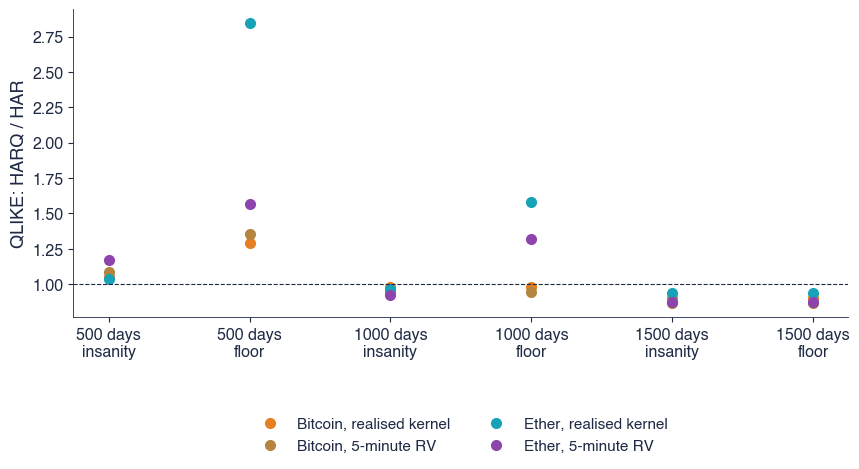

{'min': 0.8651602439847547, 'max': 2.844323807000516, 'share_better': 0.5833333333333334, 'share_sig': 0.5, 'share_worse_sig': 0.125}


In [15]:
def fig_ai_case(save_it=True):
    """QLIKE of HARQ relative to HAR for Bitcoin and Ether under 12 analysis choices: window (500, 1000, 1500 days),
    treatment of implausible forecasts (insanity filter or a floor at the smallest in-sample RV), realised measure
    (5-minute RV, realised kernel)."""
    out = {}
    rows = []
    for coin in ('btc', 'eth'):
        d = binance_daily(coin)
        for meas in ('rv5', 'rk1'):
            dd = pd.DataFrame({'rv': d[meas], 'rq': d['rq5']})
            for win in (500, 1000, 1500):
                for filt in ('insanity', 'floor'):
                    f = har_forecasts(dd, ['har', 'harq'], win=win, filt=filt)
                    q = float(qlike(f['y'], f['harq']).mean() / qlike(f['y'], f['har']).mean())
                    dm = dm_test(qlike(f['y'], f['harq']), qlike(f['y'], f['har']))
                    rows.append(dict(coin=coin, meas=meas, win=win, filt=filt, ratio=q, dm=dm))
    t = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for (coin, meas), g in t.groupby(['coin', 'meas']):
        lab = ('Bitcoin' if coin == 'btc' else 'Ether') + (', 5-minute RV' if meas == 'rv5' else ', realised kernel')
        c = {('btc', 'rv5'): st.COL['btc'], ('btc', 'rk1'): st.Orange, ('eth', 'rv5'): st.Purple, ('eth', 'rk1'): st.Teal}[(coin, meas)]
        xx = np.arange(len(g))
        ax.plot(xx, g['ratio'], 'o', color=c, ms=7, label=lab)
    ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'{w} days\n{f}' for w in (500, 1000, 1500) for f in ('insanity', 'floor')])
    ax.set_ylabel('QLIKE: HARQ / HAR')
    st.legend_outside_bottom(ax, ncol=2, y=-0.28)
    save('ats_ch8_ai_case', save_it)
    out['rows'] = rows
    out['min'] = float(t['ratio'].min())
    out['max'] = float(t['ratio'].max())
    out['share_better'] = float(np.mean(t['ratio'] < 1))
    out['share_sig'] = float(np.mean(t['dm'] < -1.96))
    out['share_worse_sig'] = float(np.mean(t['dm'] > 1.96))
    return out


r = fig_ai_case(save_it=False)
print({k: r[k] for k in r if k != 'rows'})

## Exercises

1. Replace the Parzen kernel by the Bartlett kernel in `realised_kernel` and compare the bias in the simulation.
2. Add the negative semivariance to HAR (Patton and Sheppard 2015) for the S&P 500 and evaluate it out of sample.
3. Estimate Realized GARCH with the 5-minute RV instead of the realised kernel: what happens to $\xi$ and $\varphi$?